### import the libraries

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import missingno as msno
import seaborn as sns
import requests
import math
import sympy as sp
import scipy.stats as stats
import statsmodels.api as sm
from wordcloud import WordCloud
from matplotlib.colors import ListedColormap
from matplotlib import cm

### Load the Data

In [26]:
df = pd.read_csv("C:/Users/sally/Desktop/School/Year 2/2024-25a-fai2-adsai-SallyIbrahim211066/Survey/Survey/survey_data.csv")

### Preview the dataset

In [27]:
# Display a previes and some basic info about the dataset
display(df.head())
df.info()

,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,...,Q28,Q29,Q30,Q31,Q32,Q33,Q33_4_TEXT,Q34,Q35,PROLIFIC_PID
0,Start Date,End Date,Response Type,IP Address,Progress,Duration (in seconds),Finished,Recorded Date,Response ID,Recipient Last Name,...,Which industry does your company operate in?,What is your role or department in the company?,What is the size of your company?,What is your company's annual revenue?,List of Countries,How do you describe yourself? - Selected Choice,How do you describe yourself? - Prefer to self...,What is the highest level of education you hav...,How old are you?,PROLIFIC_PID
1,"{""ImportId"":""startDate"",""timeZone"":""Europe/Ber...","{""ImportId"":""endDate"",""timeZone"":""Europe/Berlin""}","{""ImportId"":""status""}","{""ImportId"":""ipAddress""}","{""ImportId"":""progress""}","{""ImportId"":""duration""}","{""ImportId"":""finished""}","{""ImportId"":""recordedDate"",""timeZone"":""Europe/...","{""ImportId"":""_recordId""}","{""ImportId"":""recipientLastName""}",...,"{""ImportId"":""QID56""}","{""ImportId"":""QID57""}","{""ImportId"":""QID45""}","{""ImportId"":""QID5""}","{""ImportId"":""QID35""}","{""ImportId"":""QID24""}","{""ImportId"":""QID24_4_TEXT""}","{""ImportId"":""QID8""}","{""ImportId"":""QID53""}","{""ImportId"":""PROLIFIC_PID""}"
2,2024-09-30 15:25:55,2024-09-30 15:26:57,Survey Preview,NaN,100,61,True,2024-09-30 15:26:57,R_8ROpmDdiy6hYKAd,NaN,...,Healthcare and Pharmaceuticals,Operations,Fewer than 5 employees,€1 million to €5 million,Armenia,Male,NaN,Less than high school,25-34 years old,NaN
3,2024-09-30 15:34:16,2024-09-30 15:36:38,IP Address,5.146.132.253,100,141,True,2024-09-30 15:36:39,R_2lnmn9ItoIScqBw,NaN,...,Finance and Insurance,Administrative,More than 250 employees,I do not know,Germany,Male,NaN,High school diploma or equivalent,55-64 years old,6605c195e4727703228ef777
4,2024-09-30 15:33:56,2024-09-30 15:36:42,IP Address,213.81.156.126,100,166,True,2024-09-30 15:36:42,R_8hAWYwXpiTglZvR,NaN,...,Scientific or Technical Services,IT & Technical Support,More than 250 employees,€10 million to €50 million,Slovakia,Female,NaN,Bachelor's degree,25-34 years old,663ad1e9c4066faf455c913d


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Data columns (total 59 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   StartDate              179 non-null    object
 1   EndDate                179 non-null    object
 2   Status                 179 non-null    object
 3   IPAddress              178 non-null    object
 4   Progress               179 non-null    object
 5   Duration (in seconds)  179 non-null    object
 6   Finished               179 non-null    object
 7   RecordedDate           179 non-null    object
 8   ResponseId             179 non-null    object
 9   RecipientLastName      2 non-null      object
 10  RecipientFirstName     2 non-null      object
 11  RecipientEmail         2 non-null      object
 12  ExternalReference      2 non-null      object
 13  LocationLatitude       179 non-null    object
 14  LocationLongitude      179 non-null    object
 15  DistributionChannel    

In [28]:
# Display the first few rows of the dataframe
df.head()

,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,...,Q28,Q29,Q30,Q31,Q32,Q33,Q33_4_TEXT,Q34,Q35,PROLIFIC_PID
0,Start Date,End Date,Response Type,IP Address,Progress,Duration (in seconds),Finished,Recorded Date,Response ID,Recipient Last Name,...,Which industry does your company operate in?,What is your role or department in the company?,What is the size of your company?,What is your company's annual revenue?,List of Countries,How do you describe yourself? - Selected Choice,How do you describe yourself? - Prefer to self...,What is the highest level of education you hav...,How old are you?,PROLIFIC_PID
1,"{""ImportId"":""startDate"",""timeZone"":""Europe/Ber...","{""ImportId"":""endDate"",""timeZone"":""Europe/Berlin""}","{""ImportId"":""status""}","{""ImportId"":""ipAddress""}","{""ImportId"":""progress""}","{""ImportId"":""duration""}","{""ImportId"":""finished""}","{""ImportId"":""recordedDate"",""timeZone"":""Europe/...","{""ImportId"":""_recordId""}","{""ImportId"":""recipientLastName""}",...,"{""ImportId"":""QID56""}","{""ImportId"":""QID57""}","{""ImportId"":""QID45""}","{""ImportId"":""QID5""}","{""ImportId"":""QID35""}","{""ImportId"":""QID24""}","{""ImportId"":""QID24_4_TEXT""}","{""ImportId"":""QID8""}","{""ImportId"":""QID53""}","{""ImportId"":""PROLIFIC_PID""}"
2,2024-09-30 15:25:55,2024-09-30 15:26:57,Survey Preview,NaN,100,61,True,2024-09-30 15:26:57,R_8ROpmDdiy6hYKAd,NaN,...,Healthcare and Pharmaceuticals,Operations,Fewer than 5 employees,€1 million to €5 million,Armenia,Male,NaN,Less than high school,25-34 years old,NaN
3,2024-09-30 15:34:16,2024-09-30 15:36:38,IP Address,5.146.132.253,100,141,True,2024-09-30 15:36:39,R_2lnmn9ItoIScqBw,NaN,...,Finance and Insurance,Administrative,More than 250 employees,I do not know,Germany,Male,NaN,High school diploma or equivalent,55-64 years old,6605c195e4727703228ef777
4,2024-09-30 15:33:56,2024-09-30 15:36:42,IP Address,213.81.156.126,100,166,True,2024-09-30 15:36:42,R_8hAWYwXpiTglZvR,NaN,...,Scientific or Technical Services,IT & Technical Support,More than 250 employees,€10 million to €50 million,Slovakia,Female,NaN,Bachelor's degree,25-34 years old,663ad1e9c4066faf455c913d



**Research Question:**
- How do employees of SME's perceive the implementation of AI in creative fields?

**Hypothesis:**

Null Hypothesis (H₀):
H0: Employees of SMEs perceive the implementation of AI in creative fields as having no significant effect on their job performance or job satisfaction.

Alternative Hypothesis (H₁):
H1: Employees of SMEs perceive the implementation of AI in creative fields as having a significant effect (positive or negative) on their job performance or job satisfaction.

**Key Questions for Statistical Analysis**

Q11: 'AI_Concerns_In_Role', - In some professions, the use of AI is controversial. In your role, do you see any issues or concerns with using AI (e.g., an artist using AI for creative work or a doctor using AI for diagnosing patients)?

Q16: 'Barriers_to_Learning_AI' - What barriers, if any, prevent you from learning AI tools or technologies? - Selected Choice

Q21: 'AI_Impact_on_Job_Satisfaction' - Do you think the use of AI tools at your company affects your job satisfaction?

Q23: 'Comfort_with_AI_in_Work'- How comfortable are you with the idea of integrating AI tools into your daily work tasks?

Q26: 'AI_Job_Risk' - Do you believe that your company's use of AI tools puts your current job at risk?

Q5_1: 'Text_Generation_Familiarity' - How familiar are you with the following generative AI tools? - Text generation (ChatGPT, Gemini, Claude)

Q5_2: 'Image_Generation_Familiarity' - How familiar are you with the following generative AI tools? - Image generation (DALL-E, Midjourney)

### Clean the Dataset

In [29]:
# Remove the first two rows, as they contain metadata and import IDs
cleaned_data = df.drop([0, 1])

# Drop unnecessary columns like metadata (timestamps, IP address, etc.)
columns_to_drop = ['StartDate', 'EndDate', 'Status', 'IPAddress', 'Progress', 'Duration (in seconds)', 'Finished', 
                   'RecordedDate', 'ResponseId', 'RecipientLastName', 'RecipientFirstName', 'RecipientEmail', 'ExternalReference', 
                   'LocationLatitude', 'LocationLongitude', 'DistributionChannel', 'UserLanguage', 'Q2', 'Prolific-ID', 'PROLIFIC_PID']

cleaned_data = cleaned_data.drop(columns=columns_to_drop)
cleaned_data.head()

,Q3,Q4,Q5_1,Q5_2,Q5_7,Q6,Q7,Q8,Q9,Q9_9_TEXT,...,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q33_4_TEXT,Q34,Q35
2,I am aware of AI but I haven't used any AI tools,"Yes, I have used them occasionally.",5,5,7,Not very confident,"Yes, but there are some restrictions or guidel...","Yes, I have used them occasionally for work.",DALL·E,NaN,...,Definitely not,Healthcare and Pharmaceuticals,Operations,Fewer than 5 employees,€1 million to €5 million,Armenia,Male,NaN,Less than high school,25-34 years old
3,I have no knowledge of AI,"Yes, I use them regularly.",8,8,3,Neutral,"Yes, but there are some restrictions or guidel...",Rarely,"ChatGPT,Microsoft Copilot",NaN,...,Might or might not,Finance and Insurance,Administrative,More than 250 employees,I do not know,Germany,Male,NaN,High school diploma or equivalent,55-64 years old
4,"I can use AI tools such as ChatGPT, but I cann...","Yes, I have used them occasionally.",7,7,5,Not very confident,"Yes, but there are some restrictions or guidel...","Yes, I have used them occasionally for work.","ChatGPT,Microsoft Copilot",NaN,...,Probably yes,Scientific or Technical Services,IT & Technical Support,More than 250 employees,€10 million to €50 million,Slovakia,Female,NaN,Bachelor's degree,25-34 years old
5,"I can use AI tools such as ChatGPT, but I cann...","Yes, I have used them occasionally.",9,5,3,Somewhat confident,"Yes, I am allowed to use it without restrictions.","Yes, I use them regularly for my work.","ChatGPT,Microsoft Copilot",NaN,...,Probably yes,"Arts, Entertainment, and Recreation",Creative & Design,50-100 employees,I do not know,Italy,Female,NaN,Bachelor's degree,35-44 years old
6,"I can use AI tools such as ChatGPT, but I cann...",Rarely,6,0,0,Somewhat confident,"Yes, but there are some restrictions or guidel...","No, I do not use them at work.",None of the above,NaN,...,Might or might not,"Education (K-12, College, University, Adult)",Research & Development,More than 250 employees,I do not know,United Kingdom of Great Britain and Northern I...,Female,NaN,Master's degree,25-34 years old


In [30]:
# Define the mapping for renaming columns
column_rename_map = {
    'Q3': 'AI_Knowledge_Level',
    'Q4': 'AI_Use_Outside_Work',
    'Q5_1': 'Text_Generation_Familiarity',
    'Q5_2': 'Image_Generation_Familiarity',
    'Q5_7': 'Speech_Generation_Familiarity',
    'Q6': 'Confidence_in_AI_Use',
    'Q7': 'AI_Restrictions_At_Work',
    'Q8': 'AI_Use_At_Work',
    'Q9': 'AI_Tools_Used_At_Work',
    'Q9_9_TEXT': 'Other_AI_Tools_Used',
    'Q10': 'AI_Work_Applications',
    'Q10_11_TEXT': 'Other_AI_Applications',
    'Q11': 'AI_Concerns_In_Role',
    'Q12': 'Interest_in_Learning_AI',
    'Q13': 'Time_Willing_to_Learn_AI',
    'Q14': 'AI_Topics_Interest',
    'Q15': 'Preferred_Learning_Method',
    'Q15_7_TEXT': 'Other_Learning_Methods',
    'Q16': 'Barriers_to_Learning_AI',
    'Q16_9_TEXT': 'Other_Learning_Barriers',
    'Q17': 'Company_Training_Support',
    'Q18': 'Company_AI_Training_Offered',
    'Q19': 'Importance_of_AI_Training',
    'Q20': 'Job_Satisfaction',
    'Q21': 'AI_Impact_on_Job_Satisfaction',
    'Q23': 'Comfort_with_AI_in_Work',
    'Q24': 'AI_Helping_Complete_Work_Faster',
    'Q25': 'AI_Helping_Reduce_Errors',
    'Q26': 'AI_Job_Risk',
    'Q27': 'AI_Job_Security',
    'Q28': 'Company_Industry',
    'Q29': 'Company_Department',
    'Q30': 'Company_Size',
    'Q31': 'Company_Revenue',
    'Q32': 'Country_of_Residence',
    'Q33': 'Gender',
    'Q33_4_TEXT': 'Other_Gender_Description',
    'Q34': 'Education_Level',
    'Q35': 'Age'
}

# Apply the renaming to the dataframe
cleaned_data.rename(columns=column_rename_map, inplace=True)

# Display the list of column names to confirm renaming
cleaned_data.columns.to_list()


['AI_Knowledge_Level',
 'AI_Use_Outside_Work',
 'Text_Generation_Familiarity',
 'Image_Generation_Familiarity',
 'Speech_Generation_Familiarity',
 'Confidence_in_AI_Use',
 'AI_Restrictions_At_Work',
 'AI_Use_At_Work',
 'AI_Tools_Used_At_Work',
 'Other_AI_Tools_Used',
 'AI_Work_Applications',
 'Other_AI_Applications',
 'AI_Concerns_In_Role',
 'Interest_in_Learning_AI',
 'Time_Willing_to_Learn_AI',
 'AI_Topics_Interest',
 'Preferred_Learning_Method',
 'Other_Learning_Methods',
 'Barriers_to_Learning_AI',
 'Other_Learning_Barriers',
 'Company_Training_Support',
 'Company_AI_Training_Offered',
 'Importance_of_AI_Training',
 'Job_Satisfaction',
 'AI_Impact_on_Job_Satisfaction',
 'Comfort_with_AI_in_Work',
 'AI_Helping_Complete_Work_Faster',
 'AI_Helping_Reduce_Errors',
 'AI_Job_Risk',
 'AI_Job_Security',
 'Company_Industry',
 'Company_Department',
 'Company_Size',
 'Company_Revenue',
 'Country_of_Residence',
 'Gender',
 'Other_Gender_Description',
 'Education_Level',
 'Age']

In [31]:
# Get the number of rows and columns in the dataset
rows, columns = cleaned_data.shape

# Display the row and column count
print(f"Total number of rows: {rows}")
print(f"Total number of columns: {columns}")

Total number of rows: 177
Total number of columns: 39


In [32]:
# Get basic info about the dataset
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 2 to 178
Data columns (total 39 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   AI_Knowledge_Level               176 non-null    object
 1   AI_Use_Outside_Work              176 non-null    object
 2   Text_Generation_Familiarity      176 non-null    object
 3   Image_Generation_Familiarity     176 non-null    object
 4   Speech_Generation_Familiarity    176 non-null    object
 5   Confidence_in_AI_Use             176 non-null    object
 6   AI_Restrictions_At_Work          176 non-null    object
 7   AI_Use_At_Work                   176 non-null    object
 8   AI_Tools_Used_At_Work            176 non-null    object
 9   Other_AI_Tools_Used              16 non-null     object
 10  AI_Work_Applications             176 non-null    object
 11  Other_AI_Applications            3 non-null      object
 12  AI_Concerns_In_Role              176

AI_Knowledge_Level                   1
AI_Use_Outside_Work                  1
Text_Generation_Familiarity          1
Image_Generation_Familiarity         1
Speech_Generation_Familiarity        1
Confidence_in_AI_Use                 1
AI_Restrictions_At_Work              1
AI_Use_At_Work                       1
AI_Tools_Used_At_Work                1
Other_AI_Tools_Used                161
AI_Work_Applications                 1
Other_AI_Applications              174
AI_Concerns_In_Role                  1
Interest_in_Learning_AI              1
Time_Willing_to_Learn_AI             1
AI_Topics_Interest                   1
Preferred_Learning_Method            1
Other_Learning_Methods             176
Barriers_to_Learning_AI              1
Other_Learning_Barriers            171
Company_Training_Support             1
Company_AI_Training_Offered          1
Importance_of_AI_Training            1
Job_Satisfaction                     1
AI_Impact_on_Job_Satisfaction        1
Comfort_with_AI_in_Work  

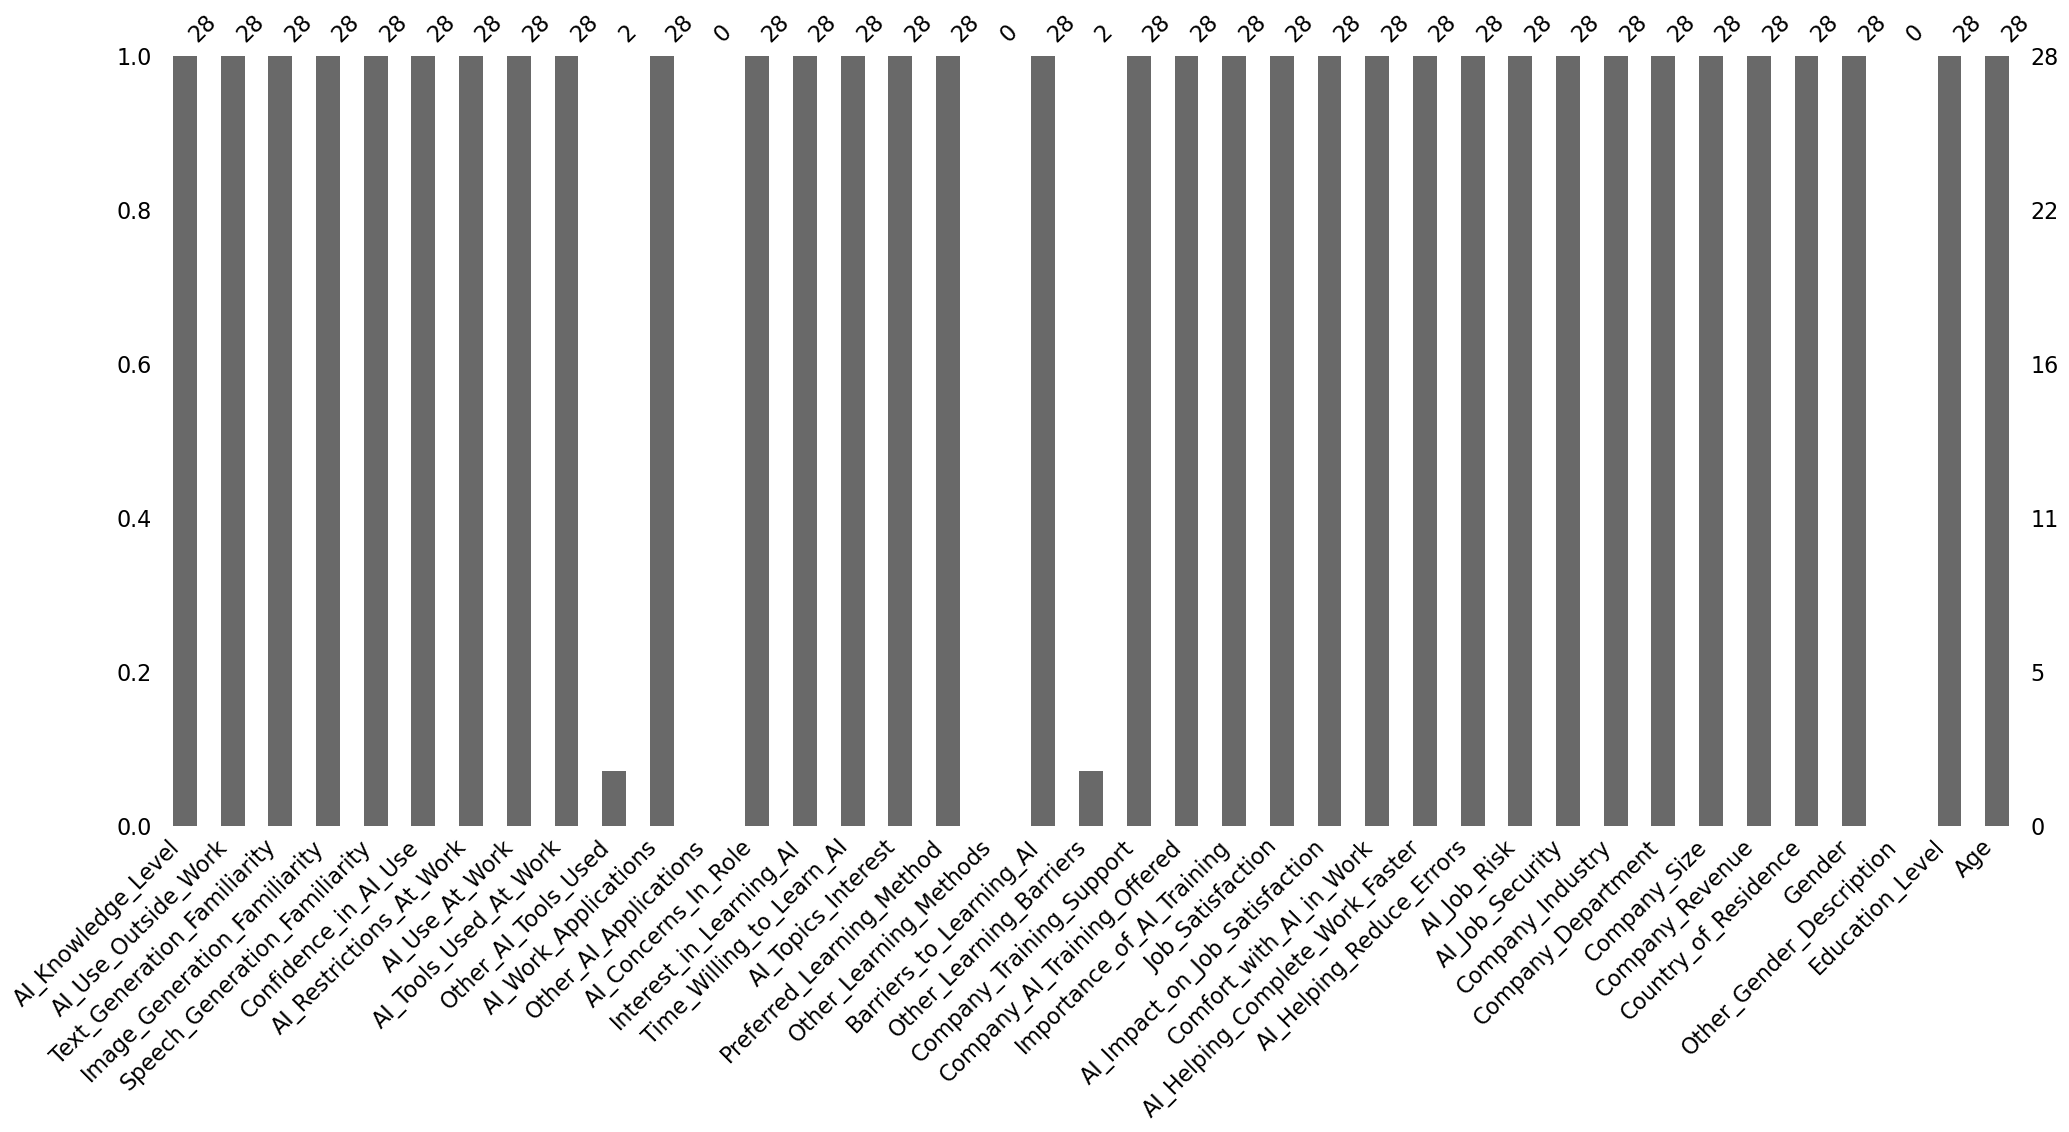

In [33]:
# Check for missing values in the dataset
missing_values = cleaned_data.isnull().sum()
print(missing_values)


# Filter rows that include 'Marketing' or 'Creative & Design' in the 'Q29' column
cleaned_data = cleaned_data[cleaned_data['Company_Department'].str.contains("marketing|creative & design", case=False, na=False)]

# Display the filtered dataframe
print(cleaned_data)


# Bar chart of missing data
msno.bar(cleaned_data)
plt.show()

all the empty rows are free text questions so the columns will be dropped

In [34]:
# Drop columns with a large amount of missing data
columns_to_drop = ['Other_AI_Tools_Used', 'Other_AI_Applications', 'Other_Learning_Methods', 'Other_Learning_Barriers', 'Other_Gender_Description']
cleaned_data = cleaned_data.drop(columns=columns_to_drop)

# Check the shape of the data after dropping columns
print(cleaned_data.shape)

(28, 34)


(28, 34)


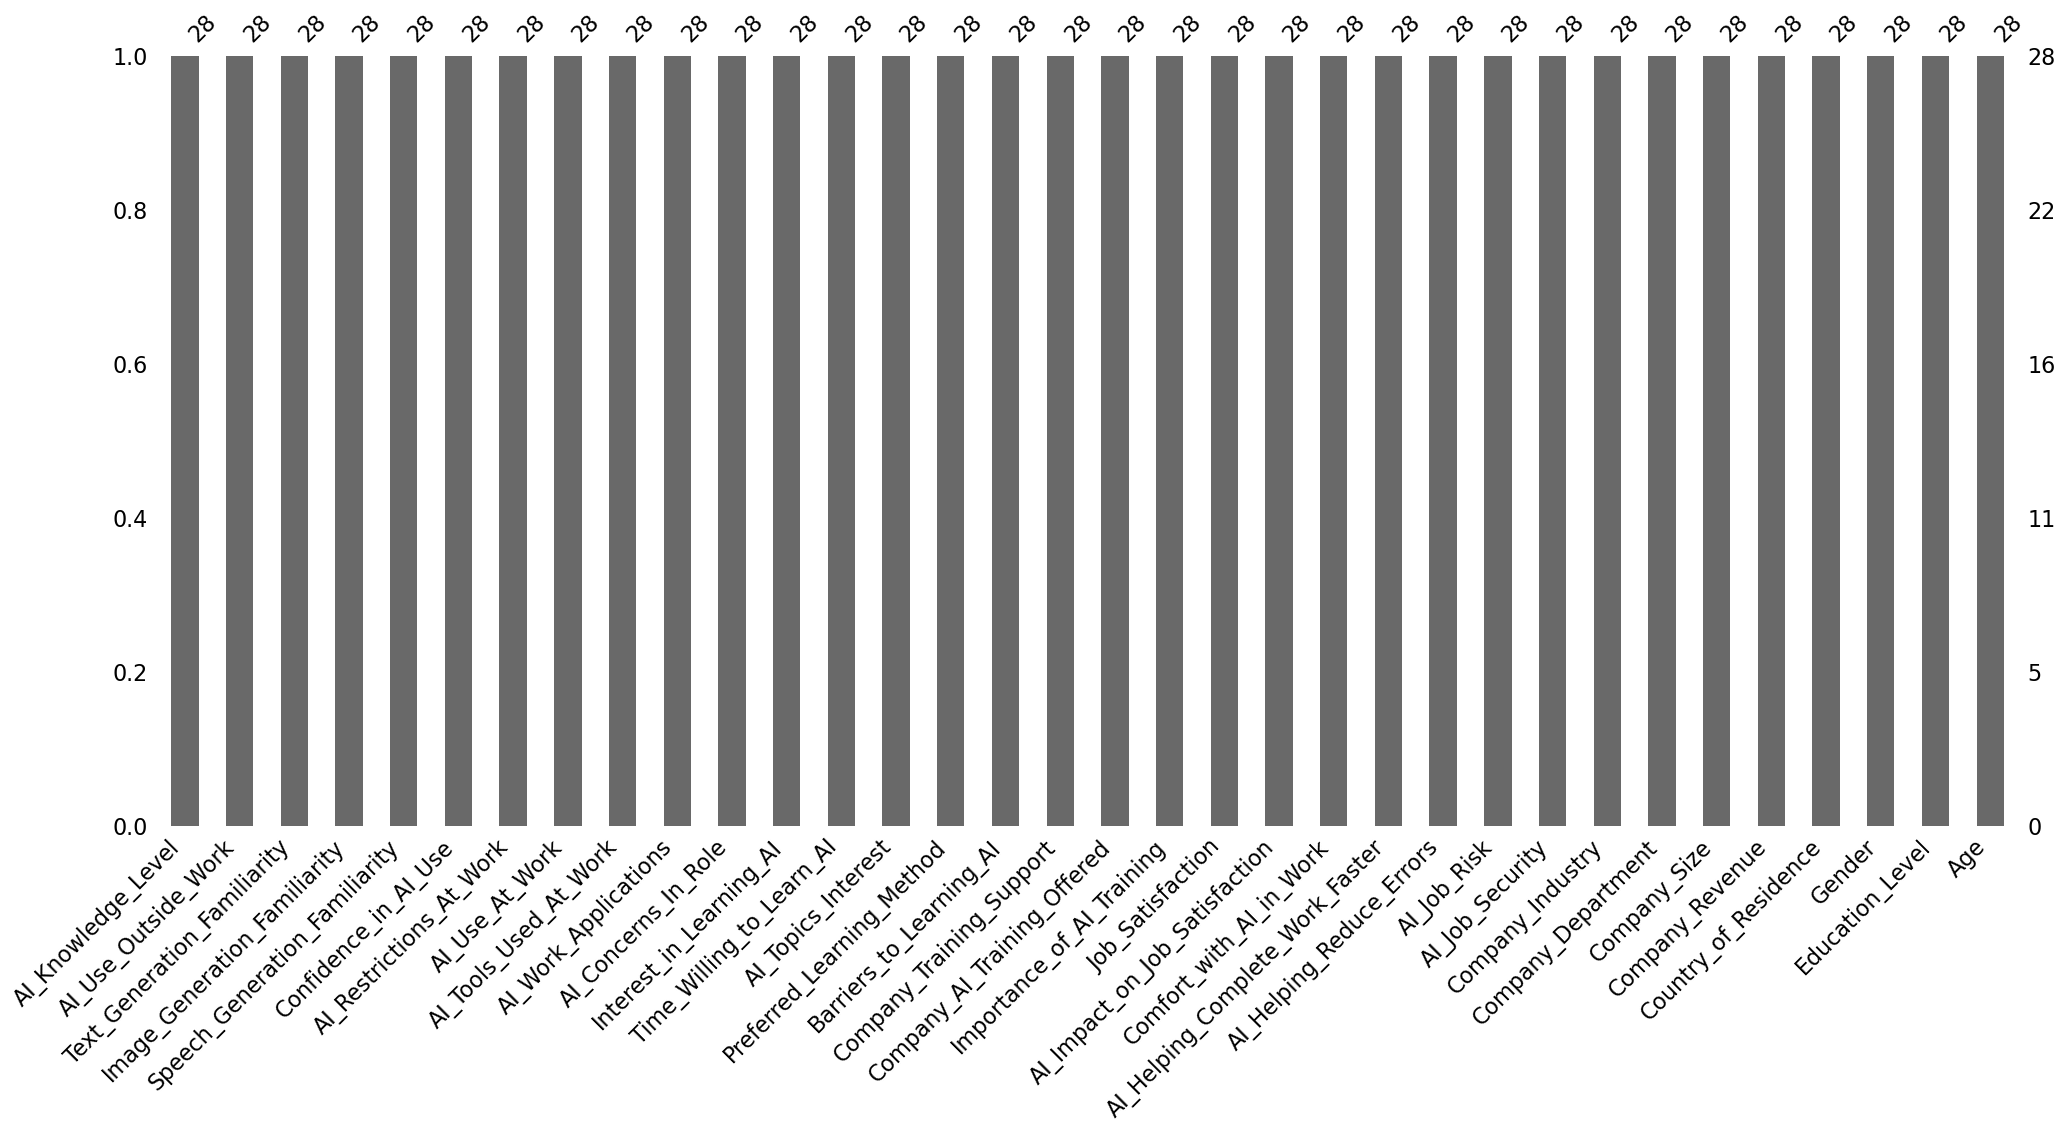

In [35]:
# Drop rows with any missing values
cleaned_data = cleaned_data.dropna()

# Verify the shape of the data after dropping the row
print(cleaned_data.shape)

# Bar chart of missing data
msno.bar(cleaned_data)
plt.show()

In [36]:
# Reset the index and drop the old index column
cleaned_data.reset_index(drop=True, inplace=True)

# Verify the new indexing
display(cleaned_data.head())

,AI_Knowledge_Level,AI_Use_Outside_Work,Text_Generation_Familiarity,Image_Generation_Familiarity,Speech_Generation_Familiarity,Confidence_in_AI_Use,AI_Restrictions_At_Work,AI_Use_At_Work,AI_Tools_Used_At_Work,AI_Work_Applications,...,AI_Job_Risk,AI_Job_Security,Company_Industry,Company_Department,Company_Size,Company_Revenue,Country_of_Residence,Gender,Education_Level,Age
0,"I can use AI tools such as ChatGPT, but I cann...","Yes, I have used them occasionally.",9,5,3,Somewhat confident,"Yes, I am allowed to use it without restrictions.","Yes, I use them regularly for my work.","ChatGPT,Microsoft Copilot","Generating content (e.g., text, images, code),...",...,Definitely yes,Probably yes,"Arts, Entertainment, and Recreation",Creative & Design,50-100 employees,I do not know,Italy,Female,Bachelor's degree,35-44 years old
1,"I can use AI tools such as ChatGPT, but I cann...","Yes, I use them regularly.",10,10,2,Somewhat confident,"Yes, I am allowed to use it without restrictions.","Yes, I have used them occasionally for work.","ChatGPT,DALL·E,MidJourney","Generating content (e.g., text, images, code),...",...,Probably not,Definitely yes,Finance and Insurance,Sales & Marketing,101-250 employees,€10 million to €50 million,Slovenia,Male,Master's degree,35-44 years old
2,"I can use AI tools such as ChatGPT, but I cann...","Yes, I have used them occasionally.",7,5,4,Neutral,I’m not sure.,Rarely,ChatGPT,"Generating content (e.g., text, images, code),...",...,Might or might not,Might or might not,Other,Sales & Marketing,10-49 employees,I do not know,Italy,Female,High school diploma or equivalent,35-44 years old
3,"I can use AI tools such as ChatGPT, but I cann...",Rarely,7,2,1,Not very confident,"Yes, I am allowed to use it without restrictions.","Yes, I have used them occasionally for work.",ChatGPT,"Generating content (e.g., text, images, code)",...,Definitely not,Probably not,Manufacturing and Engineering,Sales & Marketing,10-49 employees,€1 million to €5 million,United Kingdom of Great Britain and Northern I...,Female,Bachelor's degree,25-34 years old
4,"I can use AI tools such as ChatGPT, but I cann...","Yes, I use them regularly.",8,6,7,Somewhat confident,"Yes, but there are some restrictions or guidel...",Rarely,"ChatGPT,Google Bard,Microsoft Copilot","Customer support (e.g., chatbots),Decision-mak...",...,Probably not,Probably yes,Healthcare and Pharmaceuticals,Sales & Marketing,More than 250 employees,More than €50 million,South Africa,Female,Bachelor's degree,25-34 years old


In [37]:
cleaned_data.columns

Index(['AI_Knowledge_Level', 'AI_Use_Outside_Work',
       'Text_Generation_Familiarity', 'Image_Generation_Familiarity',
       'Speech_Generation_Familiarity', 'Confidence_in_AI_Use',
       'AI_Restrictions_At_Work', 'AI_Use_At_Work', 'AI_Tools_Used_At_Work',
       'AI_Work_Applications', 'AI_Concerns_In_Role',
       'Interest_in_Learning_AI', 'Time_Willing_to_Learn_AI',
       'AI_Topics_Interest', 'Preferred_Learning_Method',
       'Barriers_to_Learning_AI', 'Company_Training_Support',
       'Company_AI_Training_Offered', 'Importance_of_AI_Training',
       'Job_Satisfaction', 'AI_Impact_on_Job_Satisfaction',
       'Comfort_with_AI_in_Work', 'AI_Helping_Complete_Work_Faster',
       'AI_Helping_Reduce_Errors', 'AI_Job_Risk', 'AI_Job_Security',
       'Company_Industry', 'Company_Department', 'Company_Size',
       'Company_Revenue', 'Country_of_Residence', 'Gender', 'Education_Level',
       'Age'],
      dtype='object')

In [38]:
# Check unique values in the problematic columns to find unexpected values
print(cleaned_data['AI_Concerns_In_Role'].unique())
print(cleaned_data['Barriers_to_Learning_AI'].unique())
print(cleaned_data['AI_Impact_on_Job_Satisfaction'].unique())
print(cleaned_data['Comfort_with_AI_in_Work'].unique()) 
print(cleaned_data['AI_Job_Risk'].unique())
print(cleaned_data['Text_Generation_Familiarity'].unique())
print(cleaned_data['Image_Generation_Familiarity'].unique())

['Yes, I have some concerns, but I believe the benefits outweigh the risks.'
 'No, I don’t see any problems with using AI in my role.'
 'Yes, I see significant issues or concerns with using AI in my role.']
['Fear of AI replacing jobs'
 'Lack of access to resources or training,Difficulty understanding the concepts,Concern that AI may not be relevant to my role'
 'Lack of time,Lack of access to resources or training'
 'Lack of time,Lack of access to resources or training,Lack of support from management or organization'
 'Lack of access to resources or training,Lack of support from management or organization,Uncertainty about where to start'
 'Lack of time'
 'Lack of time,Lack of support from management or organization'
 'Concern that AI may not be relevant to my role,Fear of AI replacing jobs,Other'
 'Difficulty understanding the concepts,Uncertainty about where to start'
 'No significant barriers'
 'Lack of time,Lack of access to resources or training,Difficulty understanding the conce

In [39]:
'AI_Concerns_In_Role'
'Barriers_to_Learning_AI'
'AI_Impact_on_Job_Satisfaction'
'Comfort_with_AI_in_Work'
'AI_Job_Risk'
'Text_Generation_Familiarity'
'Image_Generation_Familiarity'

'Image_Generation_Familiarity'

In [40]:
# Mapping for 'AI_Concerns_In_Role'
ai_concerns_mapping = {
    'Yes, I see significant issues or concerns with using AI in my role.': 3,
    'Yes, I have some concerns, but I believe the benefits outweigh the risks.': 2,
    'I’m not sure.': 1,
    'No, I don’t see any problems with using AI in my role.': 0
}

# Mapping for 'AI_Impact_on_Job_Satisfaction'
ai_impact_mapping = {
    'Yes, AI has significantly improved my job satisfaction': 5,
    'Yes, AI has slightly improved my job satisfaction': 4,
    'AI has no impact on my job satisfaction': 3,
    'No, AI has slightly decreased my job satisfaction': 2,
    'No, AI has significantly decreased my job satisfaction': 1,
    'AI tools are not being used in my company': 0
}

# Mapping for 'Comfort_with_AI_in_Work'
comfort_mapping = {
    'Very comfortable': 4,
    'Somewhat comfortable': 3,
    'Neutral': 2,
    'Somewhat uncomfortable': 1,
    'Very uncomfortable': 0
}

# Mapping for 'AI_Job_Risk'
ai_risk_mapping = {
    'Definitely yes': 5,
    'Probably yes': 4,
    'Might or might not': 3,
    'Probably not': 2,
    'Definitely not': 1,
    'AI tools are not being used in my company': 0
}

# Apply mappings to the respective columns
cleaned_data['AI_Concerns_In_Role'] = cleaned_data['AI_Concerns_In_Role'].map(ai_concerns_mapping)
cleaned_data['AI_Impact_on_Job_Satisfaction'] = cleaned_data['AI_Impact_on_Job_Satisfaction'].map(ai_impact_mapping)
cleaned_data['Comfort_with_AI_in_Work'] = cleaned_data['Comfort_with_AI_in_Work'].map(comfort_mapping)
cleaned_data['AI_Job_Risk'] = cleaned_data['AI_Job_Risk'].map(ai_risk_mapping)

In [41]:
# Verify the encoding
print(cleaned_data[[
'AI_Concerns_In_Role',
'AI_Impact_on_Job_Satisfaction',
'Comfort_with_AI_in_Work',
'AI_Job_Risk',
'Text_Generation_Familiarity',
'Image_Generation_Familiarity']].head())

   AI_Concerns_In_Role  AI_Impact_on_Job_Satisfaction  \
0                    2                              2   
1                    2                              3   
2                    0                              3   
3                    2                              3   
4                    2                              3   

   Comfort_with_AI_in_Work  AI_Job_Risk Text_Generation_Familiarity  \
0                        2            5                           9   
1                        4            2                          10   
2                        3            3                           7   
3                        2            1                           7   
4                        3            2                           8   

  Image_Generation_Familiarity  
0                            5  
1                           10  
2                            5  
3                            2  
4                            6  


# Statistical analysis

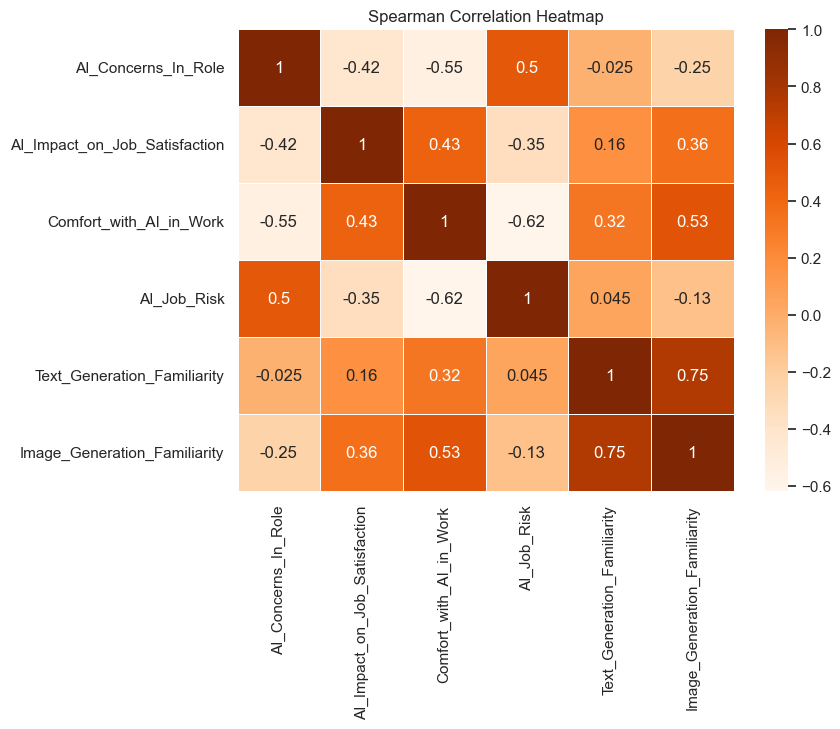

In [98]:
# Import necessary libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Select only the relevant columns for correlation analysis (excluding familiarity columns)
columns_for_correlation = [
    'AI_Concerns_In_Role',
    'AI_Impact_on_Job_Satisfaction',
    'Comfort_with_AI_in_Work',
    'AI_Job_Risk',
    'Text_Generation_Familiarity',
    'Image_Generation_Familiarity'
]

# Calculate Spearman's correlation
correlation_matrix = cleaned_data[columns_for_correlation].corr(method='spearman')

# Create a heatmap to visualize the correlation matrix with cm.Oranges color map
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap=plt.cm.Oranges, linewidths=0.5)

# Make background transparent
plt.gcf().patch.set_alpha(0)  # Set figure background transparency
plt.gca().patch.set_alpha(0)  # Set axes background transparency

# Display the heatmap
plt.title('Spearman Correlation Heatmap')
plt.show()


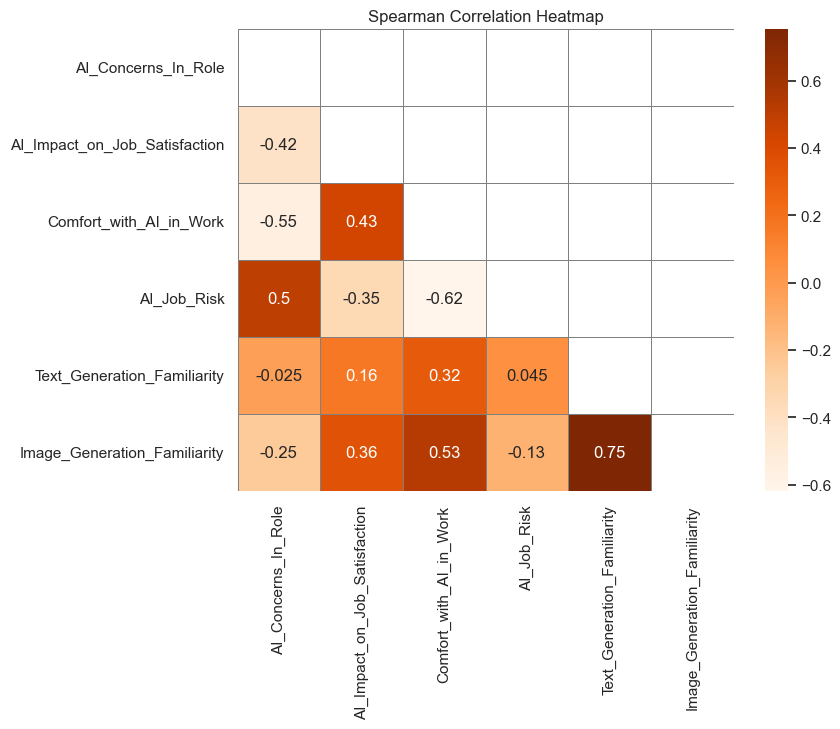

In [106]:
# Select only the relevant columns for correlation analysis (excluding familiarity columns)
columns_for_correlation = [
    'AI_Concerns_In_Role',
    'AI_Impact_on_Job_Satisfaction',
    'Comfort_with_AI_in_Work',
    'AI_Job_Risk',
    'Text_Generation_Familiarity',
    'Image_Generation_Familiarity'
]

# Calculate Spearman's correlation
correlation_matrix = cleaned_data[columns_for_correlation].corr(method='spearman')

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Create a heatmap to visualize the correlation matrix with cm.Oranges color map
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap=plt.cm.Oranges, linecolor='gray', linewidths=0.5, mask=mask)

# Make background transparent
plt.gcf().patch.set_alpha(0)  # Set figure background transparency
plt.gca().patch.set_alpha(0)  # Set axes background transparency

# Display the heatmap
plt.title('Spearman Correlation Heatmap')
plt.show()

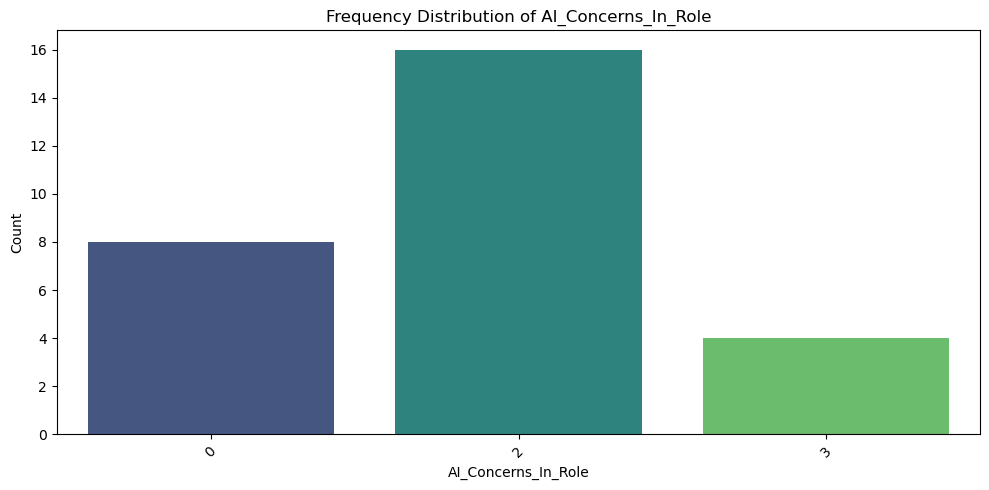

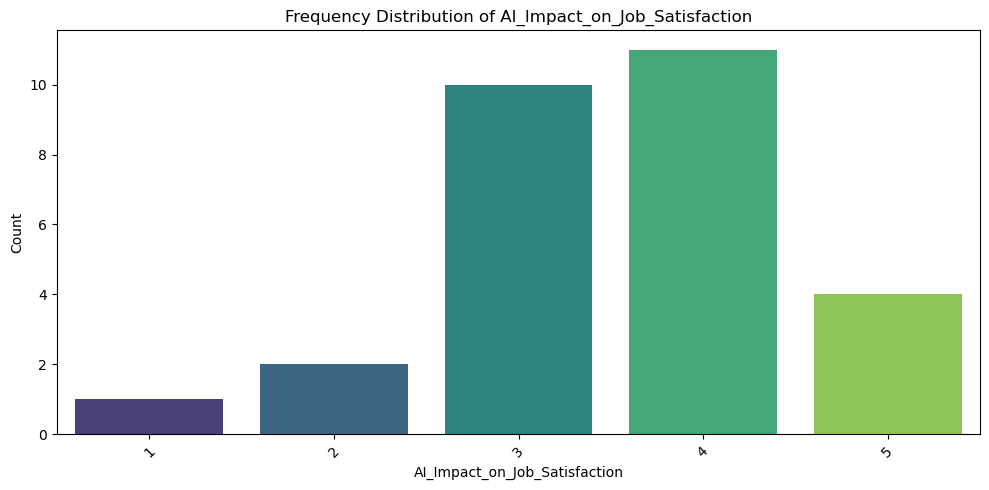

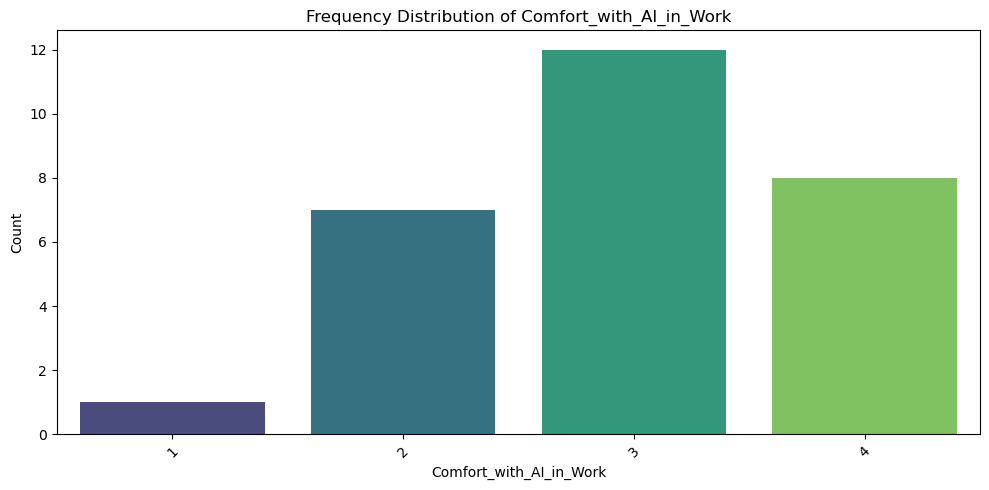

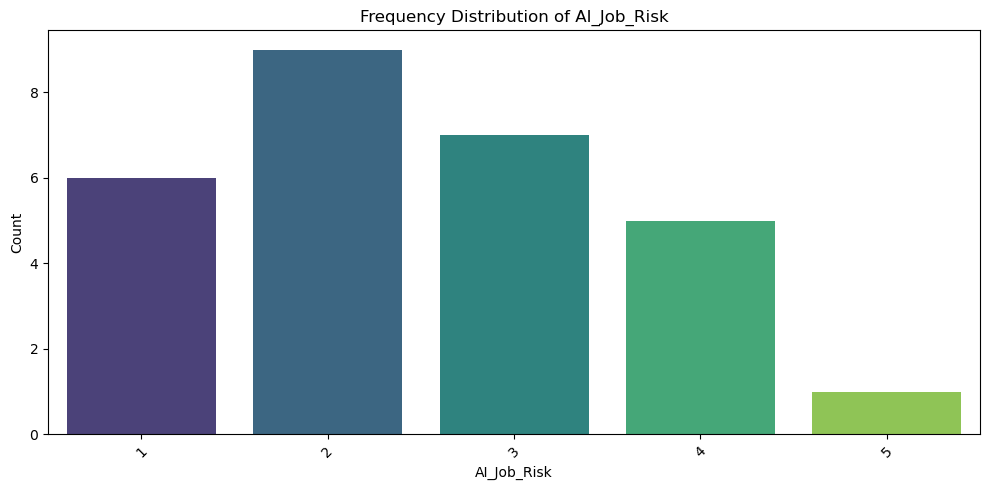

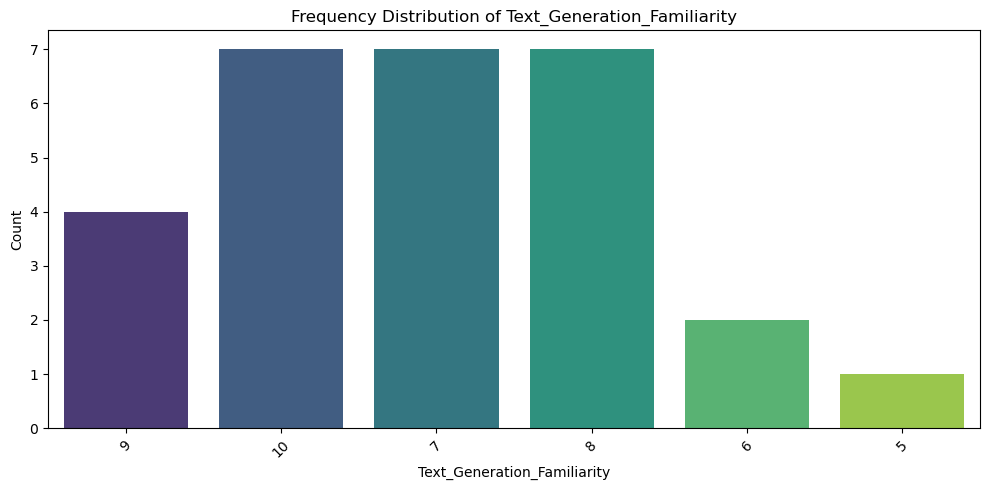

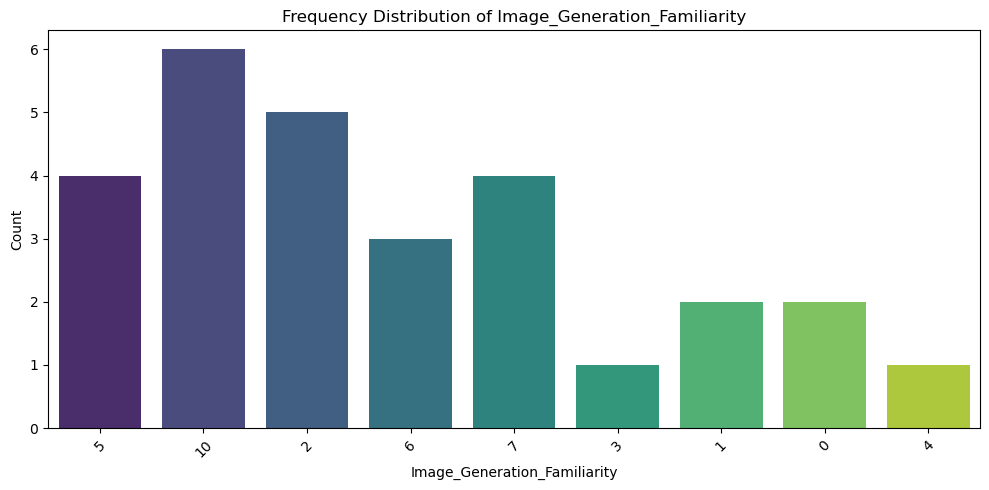

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


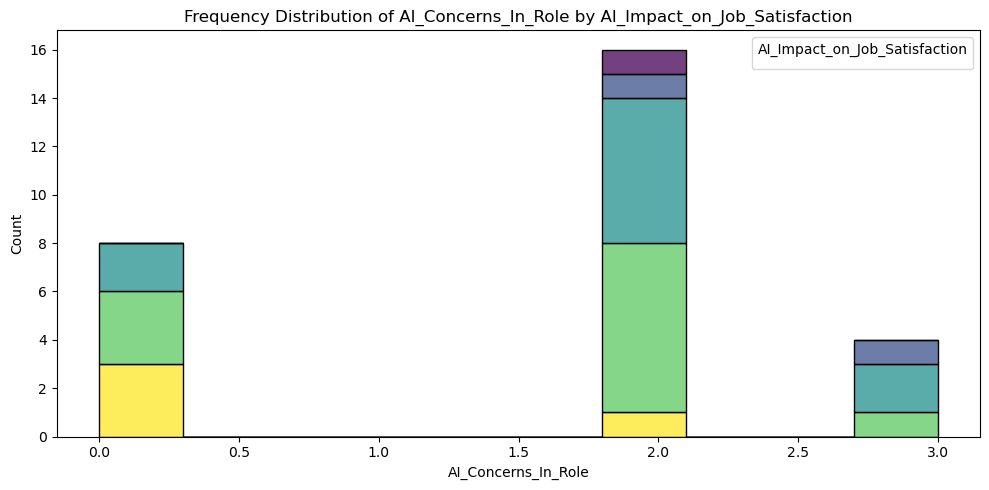

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


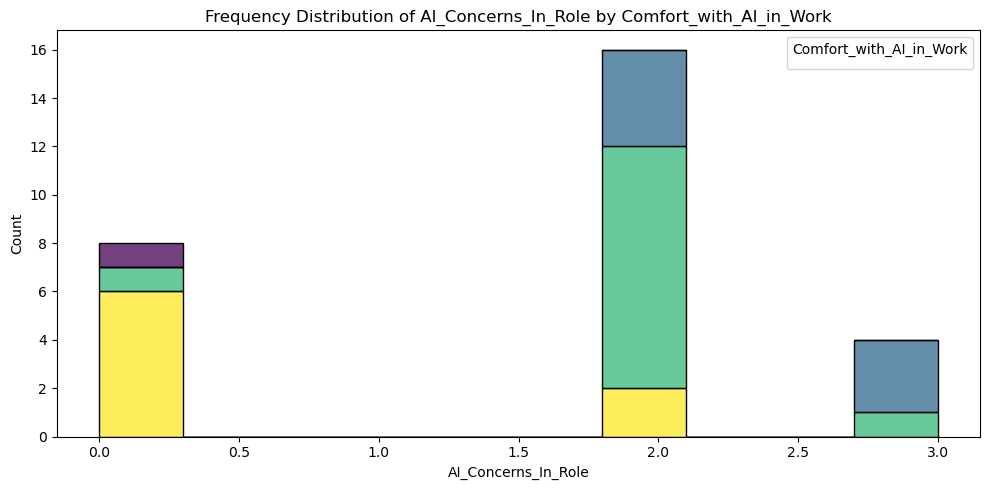

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


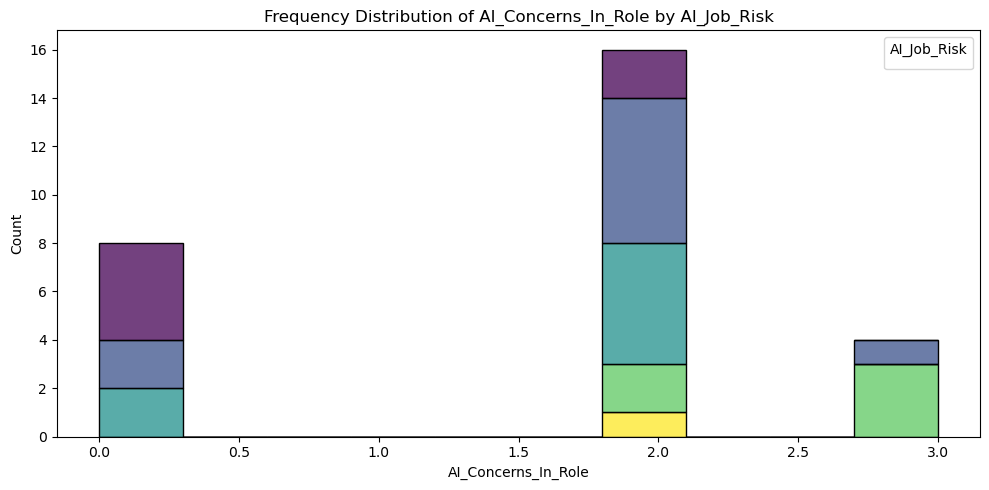

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


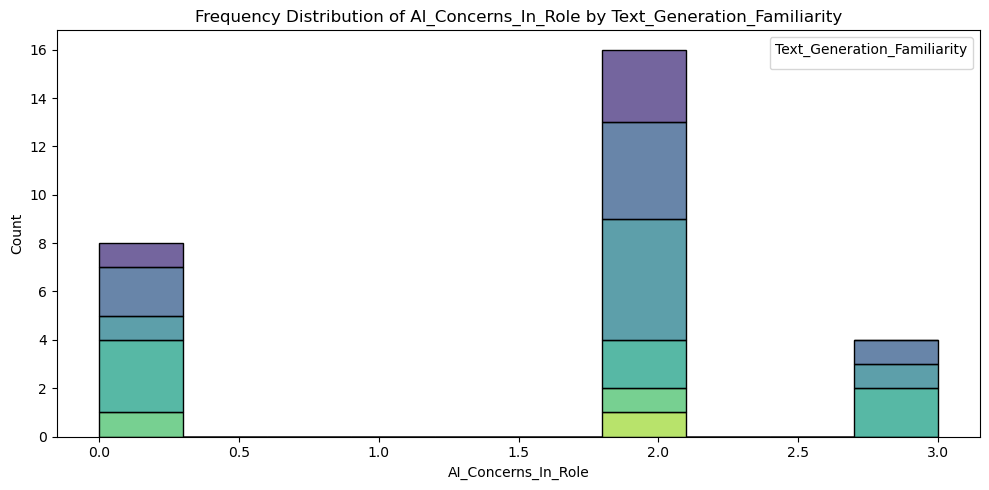

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


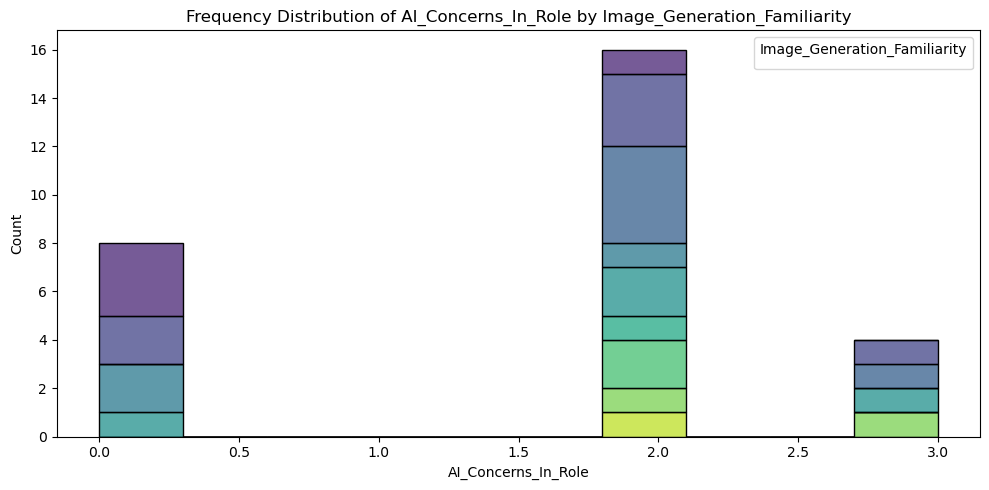

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


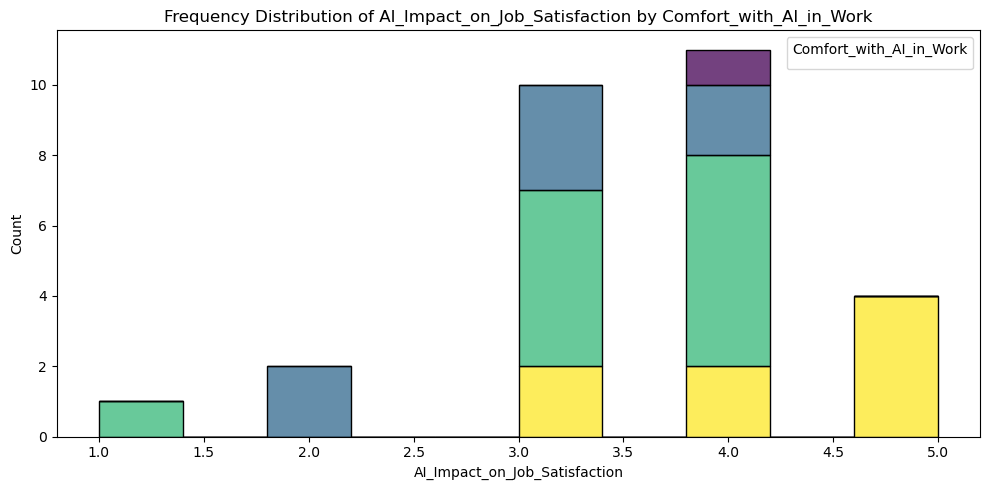

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


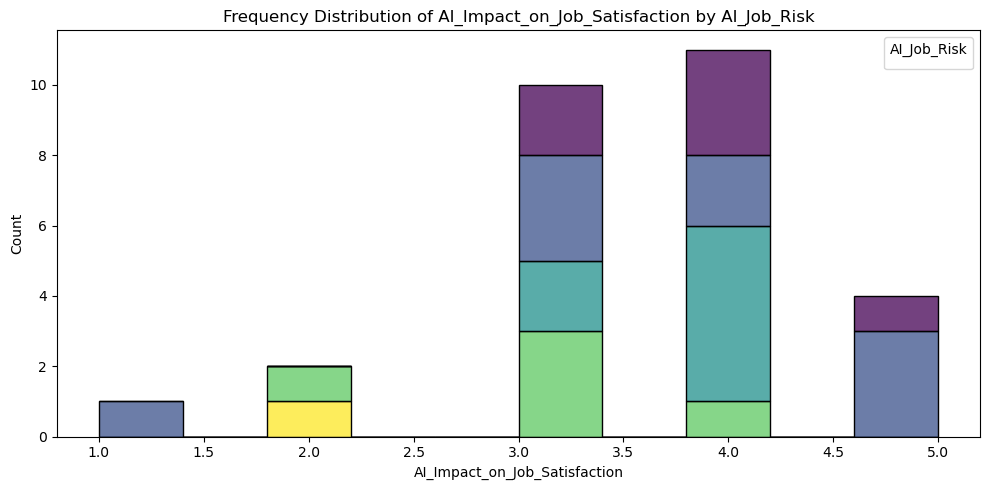

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


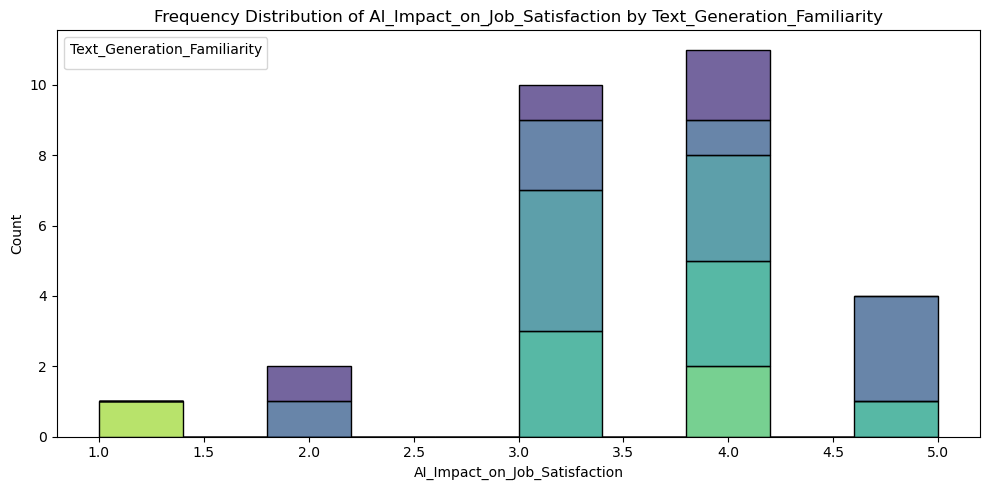

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


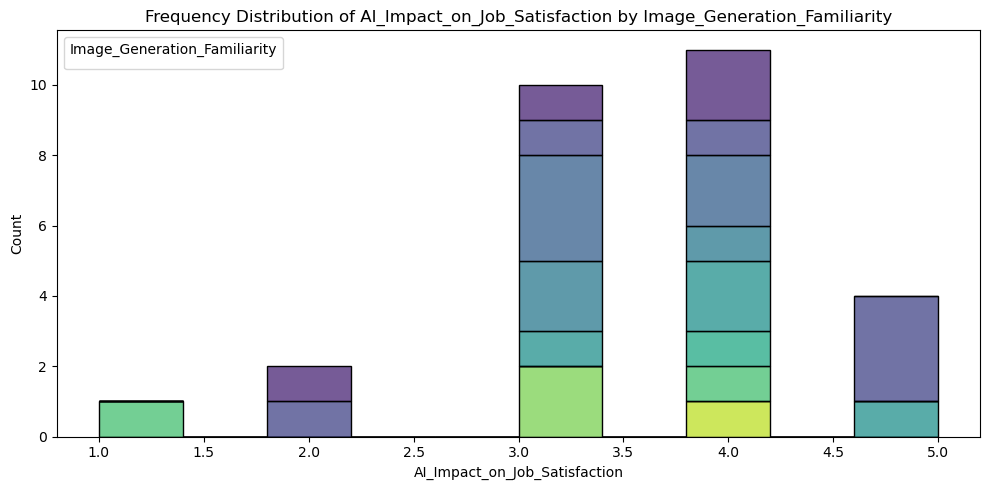

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


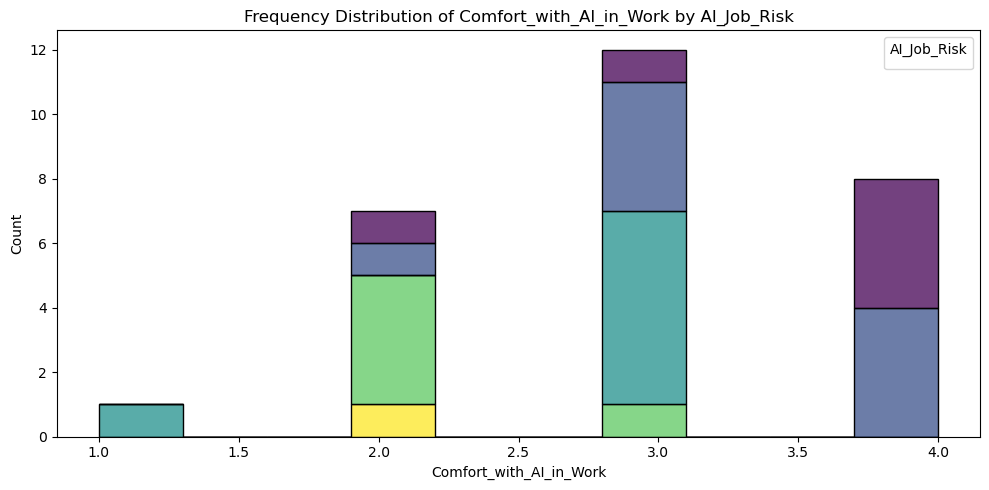

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


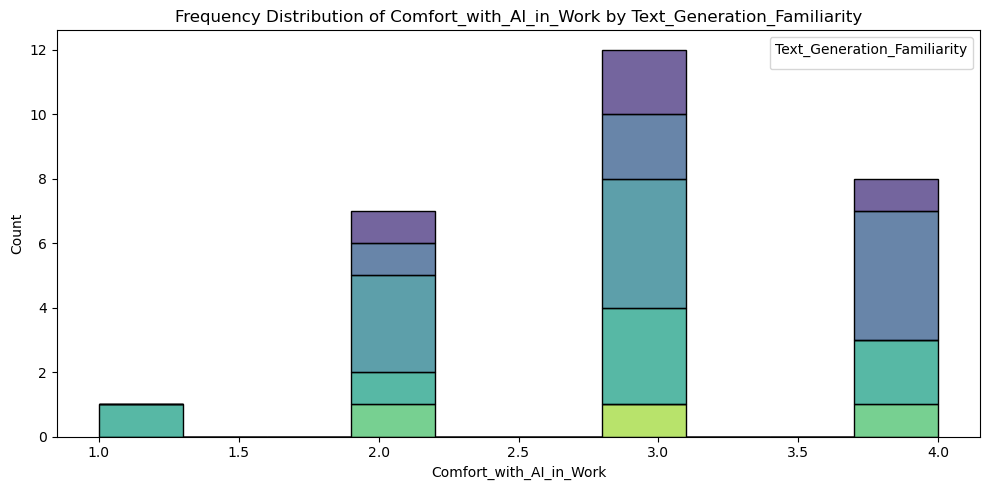

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


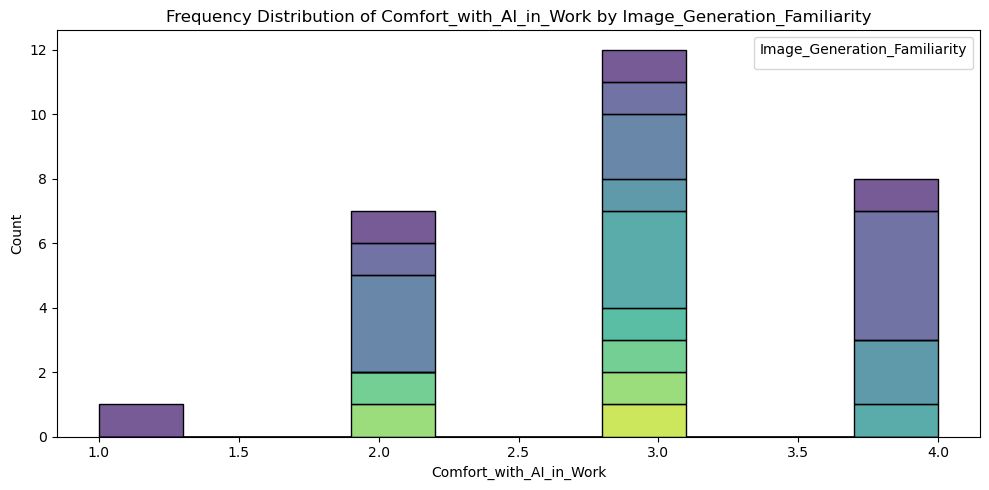

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


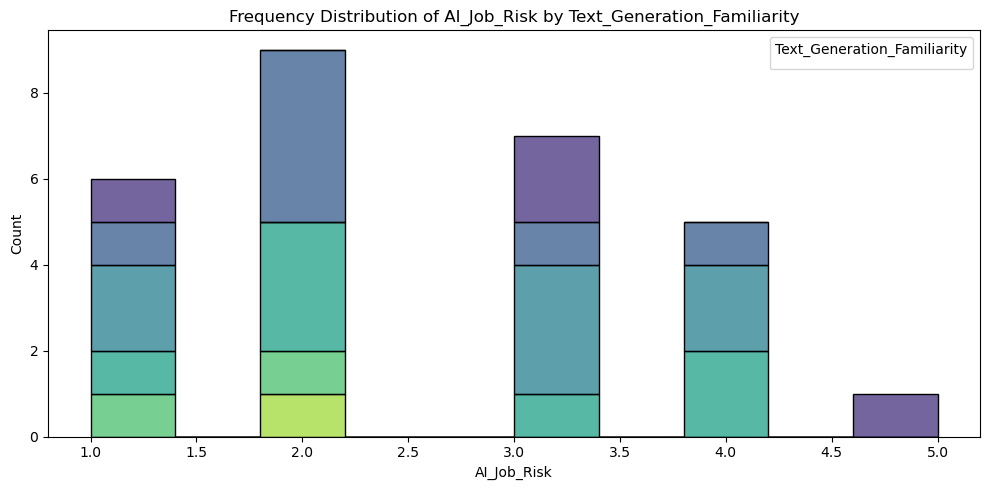

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


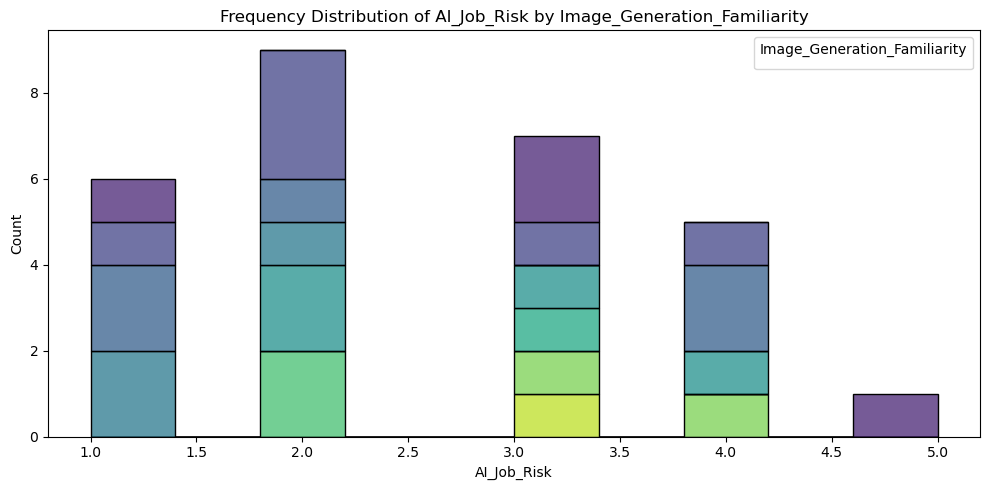

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


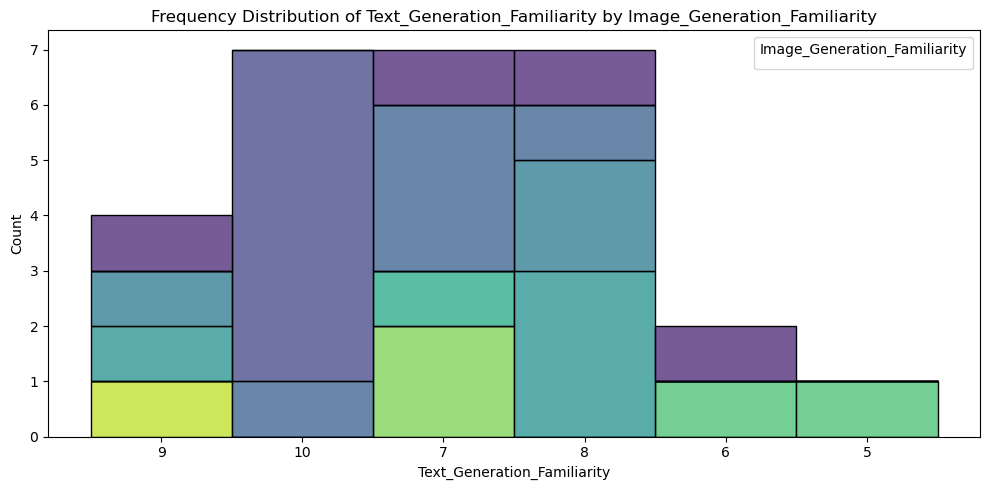

In [43]:
from itertools import combinations

# Specify the columns of interest
columns_of_interest = ['AI_Concerns_In_Role',
                       'AI_Impact_on_Job_Satisfaction',
                       'Comfort_with_AI_in_Work',
                       'AI_Job_Risk',
                       'Text_Generation_Familiarity',
                       'Image_Generation_Familiarity']

# Generate frequency distribution plots for each column
for col in columns_of_interest:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=cleaned_data, x=col, palette='viridis')
    plt.title(f'Frequency Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Generate frequency distribution for all combinations of columns
for col1, col2 in combinations(columns_of_interest, 2):
    plt.figure(figsize=(10, 5))
    sns.histplot(data=cleaned_data, x=col1, hue=col2, multiple='stack', palette='viridis', bins=10)
    plt.title(f'Frequency Distribution of {col1} by {col2}')
    plt.xlabel(col1)
    plt.ylabel('Count')
    plt.legend(title=col2)
    plt.tight_layout()
    plt.show()

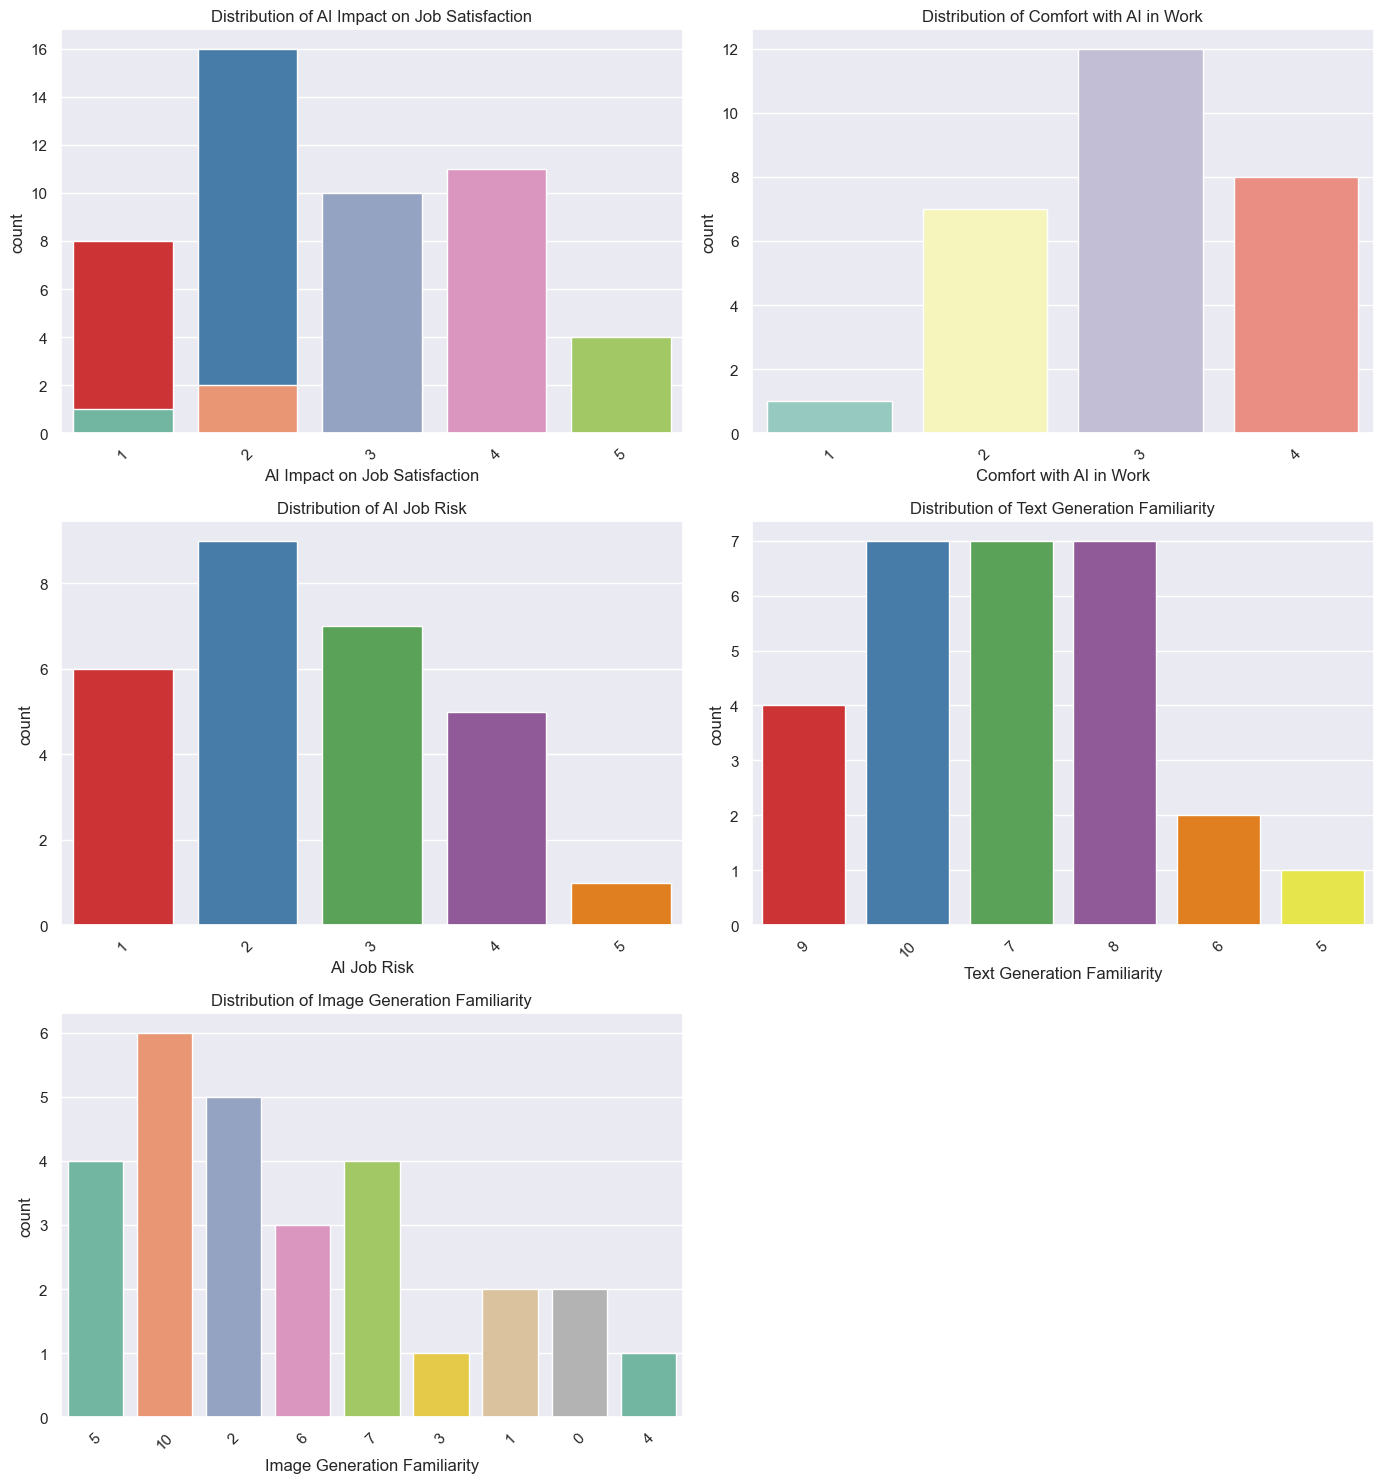

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot aesthetics
sns.set(style="darkgrid")

# Define relevant columns for analysis
relevant_columns = {
    'AI_Concerns_In_Role': 'AI Concerns In Role',
    'AI_Impact_on_Job_Satisfaction': 'AI Impact on Job Satisfaction',
    'Comfort_with_AI_in_Work': 'Comfort with AI in Work',
    'AI_Job_Risk': 'AI Job Risk',
    'Text_Generation_Familiarity': 'Text Generation Familiarity',
    'Image_Generation_Familiarity': 'Image Generation Familiarity'
}

# Ensure the columns exist in the dataframe
available_columns = {key: relevant_columns[key] for key in relevant_columns if key in cleaned_data.columns}

# Subset the dataframe to include only relevant columns
df_relevant = cleaned_data[list(available_columns.keys())].rename(columns=available_columns)

# Plot distributions of the relevant columns
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

#plot AI Concerns In Role distribution
sns.countplot(data=df_relevant, x='AI Concerns In Role', ax=axes[0, 0], palette='Set1') 
axes[0, 0].set_title('Distribution of AI Concerns In Role')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot AI Impact on Job Satisfaction distribution
sns.countplot(data=df_relevant, x='AI Impact on Job Satisfaction', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Distribution of AI Impact on Job Satisfaction')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot Comfort with AI in Work distribution
sns.countplot(data=df_relevant, x='Comfort with AI in Work', ax=axes[0, 1], palette='Set3')
axes[0, 1].set_title('Distribution of Comfort with AI in Work')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot AI Job Risk distribution
sns.countplot(data=df_relevant, x='AI Job Risk', ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Distribution of AI Job Risk')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot Text Generation Familiarity distribution
sns.countplot(data=df_relevant, x='Text Generation Familiarity', ax=axes[1, 1], palette='Set1')
axes[1, 1].set_title('Distribution of Text Generation Familiarity')
axes[1, 1].tick_params(axis='x', rotation=45)

# Plot Image Generation Familiarity distribution
sns.countplot(data=df_relevant, x='Image Generation Familiarity', ax=axes[2, 0], palette='Set2')
axes[2, 0].set_title('Distribution of Image Generation Familiarity')
axes[2, 0].tick_params(axis='x', rotation=45)

# Remove the empty subplot
fig.delaxes(axes[2, 1])

# Adjust layout
plt.tight_layout()
plt.show()

In [45]:
# Descriptive statistics
descriptive_stats = cleaned_data['AI_Concerns_In_Role'].describe(include='all')
print(descriptive_stats)

descriptive_stats = cleaned_data['AI_Impact_on_Job_Satisfaction'].describe(include='all')
print(descriptive_stats)

descriptive_stats = cleaned_data['Comfort_with_AI_in_Work'].describe(include='all')
print(descriptive_stats)

descriptive_stats = cleaned_data['AI_Job_Risk'].describe(include='all')
print(descriptive_stats) 


count    28.000000
mean      1.571429
std       1.069045
min       0.000000
25%       0.000000
50%       2.000000
75%       2.000000
max       3.000000
Name: AI_Concerns_In_Role, dtype: float64
count    28.000000
mean      3.535714
std       0.961563
min       1.000000
25%       3.000000
50%       4.000000
75%       4.000000
max       5.000000
Name: AI_Impact_on_Job_Satisfaction, dtype: float64
count    28.000000
mean      2.964286
std       0.838082
min       1.000000
25%       2.000000
50%       3.000000
75%       4.000000
max       4.000000
Name: Comfort_with_AI_in_Work, dtype: float64
count    28.00000
mean      2.50000
std       1.13855
min       1.00000
25%       2.00000
50%       2.00000
75%       3.00000
max       5.00000
Name: AI_Job_Risk, dtype: float64


### T-Test and P-values

In [46]:
# 3. T-Test (Example: AI Satisfaction by AI Concerns)
group1 = cleaned_data[cleaned_data['AI_Impact_on_Job_Satisfaction'] >= 4]['AI_Concerns_In_Role']
group2 = cleaned_data[cleaned_data['AI_Impact_on_Job_Satisfaction'] <= 2]['AI_Concerns_In_Role']
t_stat, p_val = stats.ttest_ind(group1, group2)
print(f'T-test results: T-Stat={t_stat}, P-Value={p_val}')

T-test results: T-Stat=-1.6080605044147398, P-Value=0.12737336220803114


In [47]:
# Define the columns of interest
columns_of_interest = [
    'AI_Concerns_In_Role',
    'AI_Impact_on_Job_Satisfaction',
    'Comfort_with_AI_in_Work',
    'AI_Job_Risk'
]

# Store results in a DataFrame
results = []

# Loop through all combinations of the columns
for col1, col2 in combinations(columns_of_interest, 2):
    # Group data based on a threshold (e.g., median) for one of the columns
    # Ensure the columns contain numeric data
    cleaned_data[col1] = pd.to_numeric(cleaned_data[col1], errors='coerce')
    cleaned_data[col2] = pd.to_numeric(cleaned_data[col2], errors='coerce')
    
    median_col1 = cleaned_data[col1].median()
    group1 = cleaned_data[cleaned_data[col1] >= median_col1][col2]
    group2 = cleaned_data[cleaned_data[col1] < median_col1][col2]
    
    # Perform the t-test
    t_stat, p_val = stats.ttest_ind(group1, group2, nan_policy='omit')

    # Store the results
    results.append({
        'Column 1': col1,
        'Column 2': col2,
        'T-Statistic': t_stat,
        'P-Value': p_val
    })

# Convert results to a DataFrame for better readability
results_cleaned_data = pd.DataFrame(results)

# Display results
print(results_cleaned_data)

                        Column 1                       Column 2  T-Statistic  \
0            AI_Concerns_In_Role  AI_Impact_on_Job_Satisfaction    -2.190473   
1            AI_Concerns_In_Role        Comfort_with_AI_in_Work    -2.303502   
2            AI_Concerns_In_Role                    AI_Job_Risk     2.388999   
3  AI_Impact_on_Job_Satisfaction        Comfort_with_AI_in_Work     1.153501   
4  AI_Impact_on_Job_Satisfaction                    AI_Job_Risk    -1.534831   
5        Comfort_with_AI_in_Work                    AI_Job_Risk    -2.904666   

    P-Value  
0  0.037652  
1  0.029501  
2  0.024440  
3  0.259199  
4  0.136906  
5  0.007409  


Null and Alternative Hypotheses
Null Hypothesis (H₀): Employees of SMEs perceive the implementation of AI in creative fields as having no significant effect on their job performance or job satisfaction.

Alternative Hypothesis (H₁): Employees of SMEs perceive the implementation of AI in creative fields as having a significant effect (positive or negative) on their job performance or job satisfaction.
Results Breakdown



Comparison: 

1. AI_Concerns_In_Role vs. AI_Impact_on_Job_Satisfaction

T-Statistic: -2.190473
P-Value: 0.037652
Interpretation: The negative T-statistic suggests that higher concerns about AI in their role are associated with lower job satisfaction. The P-value is less than 0.05, which indicates that we can reject the null hypothesis at the 5% significance level. This implies that there is a statistically significant relationship between AI concerns and job satisfaction.


Comparison: 

2. AI_Concerns_In_Role vs. Comfort_with_AI_in_Work

T-Statistic: -2.303502
P-Value: 0.029501
Interpretation: Similar to the previous comparison, this negative T-statistic indicates that those who are more concerned about AI in their roles tend to feel less comfortable with integrating AI into their work. The P-value is again below 0.05, allowing us to reject the null hypothesis. This result suggests a significant effect of AI concerns on comfort with AI.


Comparison: 

3. AI_Concerns_In_Role vs. AI_Job_Risk

T-Statistic: 2.388999
P-Value: 0.024440
Interpretation: Here, the positive T-statistic implies that employees who have higher concerns about AI in their role perceive a greater risk to their jobs from AI. The P-value is also less than 0.05, indicating a statistically significant relationship. This supports the alternative hypothesis, suggesting that concerns about AI relate to perceived job risk.


Comparison: 

4. AI_Impact_on_Job_Satisfaction vs. Comfort_with_AI_in_Work

T-Statistic: 1.153501
P-Value: 0.259199
Interpretation: The positive T-statistic indicates a tendency towards higher job satisfaction associated with comfort in using AI. However, the P-value is greater than 0.05, meaning we fail to reject the null hypothesis. Thus, this result does not suggest a significant relationship between job satisfaction and comfort with AI.


Comparison: 

5. AI_Impact_on_Job_Satisfaction vs. AI_Job_Risk

T-Statistic: -1.534831
P-Value: 0.136906
Interpretation: The negative T-statistic indicates that higher perceived job risk is associated with lower job satisfaction. However, the P-value exceeds 0.05, so we fail to reject the null hypothesis here. This suggests no significant evidence that job risk affects job satisfaction.


Comparison: 

6.

Comfort_with_AI_in_Work vs. AI_Job_Risk

T-Statistic: -2.904666
P-Value: 0.007409
Interpretation: This negative T-statistic indicates that employees who are more comfortable with AI perceive less risk to their jobs. The P-value is below 0.01, leading us to reject the null hypothesis at the 1% significance level. This strongly suggests a significant relationship, meaning that comfort with AI is associated with lower perceived job risk.



Summary
In summary, your results indicate several significant relationships between employee perceptions of AI and factors like job satisfaction, comfort with AI, and job risk. The first three comparisons show that concerns about AI negatively affect job satisfaction and comfort while increasing perceived job risk, providing strong support for your alternative hypothesis. The last two comparisons reveal that comfort with AI is significantly related to perceptions of job risk, reinforcing the importance of employee attitudes towards AI implementation in creative fields.

### ANOVA

In [48]:
import itertools

# Specify the columns of interest
columns_of_interest = [
    'AI_Concerns_In_Role',
    'AI_Impact_on_Job_Satisfaction',
    'Comfort_with_AI_in_Work',
    'AI_Job_Risk'
]

# Perform ANOVA for each combination of columns
anova_results = {}

for col1, col2 in itertools.combinations(columns_of_interest, 2):
    # Group the data by unique values of col1
    groups = [cleaned_data[cleaned_data[col1] == value][col2] for value in cleaned_data[col1].unique() if value in cleaned_data[col1].values]
    
    # Perform ANOVA
    f_val, p_val = stats.f_oneway(*groups)
    
    # Store results
    anova_results[(col1, col2)] = {'F-value': f_val, 'P-value': p_val}

# Display the ANOVA results
for (col1, col2), results in anova_results.items():
    print(f'ANOVA results for {col1} and {col2}: F-value = {results["F-value"]:.4f}, P-value = {results["P-value"]:.4f}')

ANOVA results for AI_Concerns_In_Role and AI_Impact_on_Job_Satisfaction: F-value = 2.6299, P-value = 0.0919
ANOVA results for AI_Concerns_In_Role and Comfort_with_AI_in_Work: F-value = 3.8485, P-value = 0.0349
ANOVA results for AI_Concerns_In_Role and AI_Job_Risk: F-value = 4.1667, P-value = 0.0274
ANOVA results for AI_Impact_on_Job_Satisfaction and Comfort_with_AI_in_Work: F-value = 2.9483, P-value = 0.0419
ANOVA results for AI_Impact_on_Job_Satisfaction and AI_Job_Risk: F-value = 2.5677, P-value = 0.0652
ANOVA results for Comfort_with_AI_in_Work and AI_Job_Risk: F-value = 5.5718, P-value = 0.0048


Hypothesis Context
Null Hypothesis (H₀): Employees of SMEs perceive the implementation of AI in creative fields as having no significant effect on their job performance or job satisfaction.

Alternative Hypothesis (H₁): Employees of SMEs perceive the implementation of AI in creative fields as having a significant effect (positive or negative) on their job performance or job satisfaction.
ANOVA Results Analysis


1. AI_Concerns_In_Role and AI_Impact_on_Job_Satisfaction

F-value = 2.6299
P-value = 0.0919
Interpretation: The F-value suggests that there is some variability in job satisfaction based on concerns about AI in their roles. However, the p-value (0.0919) is above the common alpha level of 0.05, indicating that we fail to reject the null hypothesis. This result suggests that concerns about AI do not significantly affect perceived job satisfaction at the 5% level, but it may be worth exploring further as it approaches significance.


2. AI_Concerns_In_Role and Comfort_with_AI_in_Work

F-value = 3.8485
P-value = 0.0349
Interpretation: This result indicates a statistically significant difference in comfort with AI based on the level of concern about AI in their roles (p < 0.05). This suggests that higher concerns about AI are associated with lower comfort levels. This supports the alternative hypothesis (H₁), implying that concerns about AI have a significant impact on how comfortable employees feel using AI tools.


3. AI_Concerns_In_Role and AI_Job_Risk

F-value = 4.1667
P-value = 0.0274
Interpretation: The p-value indicates a significant result (p < 0.05), suggesting that there is a significant effect of AI concerns on perceived job risk. This supports H₁, indicating that employees who are more concerned about AI are more likely to perceive a higher risk to their jobs from AI implementation.


4. AI_Impact_on_Job_Satisfaction and Comfort_with_AI_in_Work

F-value = 2.9483
P-value = 0.0419
Interpretation: With a p-value below 0.05, this result indicates a significant relationship between job satisfaction and comfort with AI. Higher comfort levels with AI tools are associated with improved job satisfaction, supporting the alternative hypothesis (H₁) that comfort with AI affects job performance and satisfaction.


5. AI_Impact_on_Job_Satisfaction and AI_Job_Risk

F-value = 2.5677
P-value = 0.0652
Interpretation: The p-value (0.0652) is slightly above 0.05, suggesting that we do not reject the null hypothesis at the 5% significance level. However, it is close enough to indicate a potential effect, suggesting that perceptions of job risk from AI may influence job satisfaction, which warrants further investigation.


6. Comfort_with_AI_in_Work and AI_Job_Risk

F-value = 5.5718
P-value = 0.0048
Interpretation: This result shows a strong significant relationship (p < 0.01) between comfort with AI and perceived job risk. It indicates that employees who are more comfortable using AI tools perceive less risk to their jobs. This supports the alternative hypothesis (H₁) and suggests that increasing comfort with AI could mitigate perceived job risk.


Summary
Significant Results: The analyses for AI_Concerns_In_Role with Comfort_with_AI_in_Work, AI_Job_Risk, AI_Impact_on_Job_Satisfaction with Comfort_with_AI_in_Work, and Comfort_with_AI_in_Work with AI_Job_Risk showed significant effects. These support the alternative hypothesis (H₁), indicating that perceptions about AI indeed have meaningful impacts on job performance and satisfaction.
Non-significant Results: The relationships involving AI_Impact_on_Job_Satisfaction with AI_Concerns_In_Role and AI_Job_Risk were not significant at the 5% level, although some results approached significance, suggesting potential areas for further research.

Overall, the results suggest that while concerns about AI do not significantly affect job satisfaction, they do significantly relate to comfort levels and perceived job risks. Higher comfort with AI is associated with lower perceived job risk and a more positive view of AI's impact on job satisfaction. The evidence supports the idea that employees’ perceptions of AI have nuanced effects on their experience at work, thus indicating significant relationships worth further exploration.

--------------


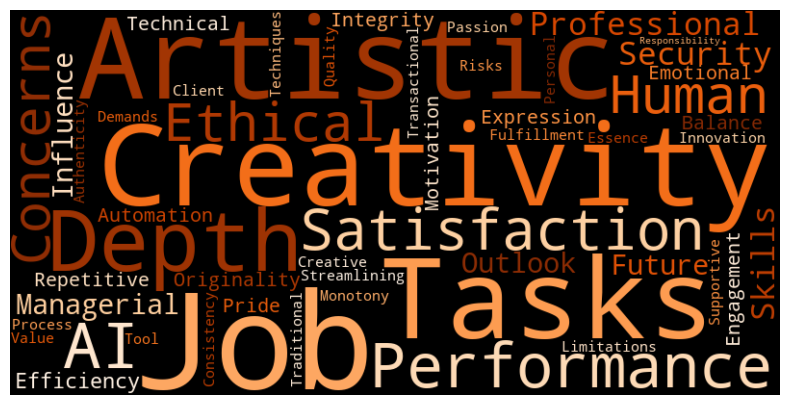

In [96]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Define the qualitative text data
text = """
AI Creativity Job Performance Job Satisfaction Ethical Concerns Human Creativity
Professional Skills Job Security Managerial Influence Future Outlook Efficiency Originality
Integrity Artistic Expression Repetitive Tasks Automation Emotional Depth Technical Tasks
Engagement Motivation Pride Balance Streamlining Limitations Risks Value Authenticity
Client Demands Fulfillment Consistency Depth Supportive Tool Personal Essence Transactional Monotony
Passion Artistic Quality Innovation Traditional Techniques Creative Process Responsibility
"""

# Generate the word cloud with a specific colormap
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color=None,
    colormap='Oranges',  # Set the colormap to 'Oranges'
    collocations=False
).generate(text)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")

# Make background transparent
plt.axis("off")

# Save the word cloud with a transparent background
plt.savefig("wordcloud.png", format='png', transparent=True)

# Display the word cloud
plt.show()


c:\Users\sally\anaconda3\envs\block_b\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


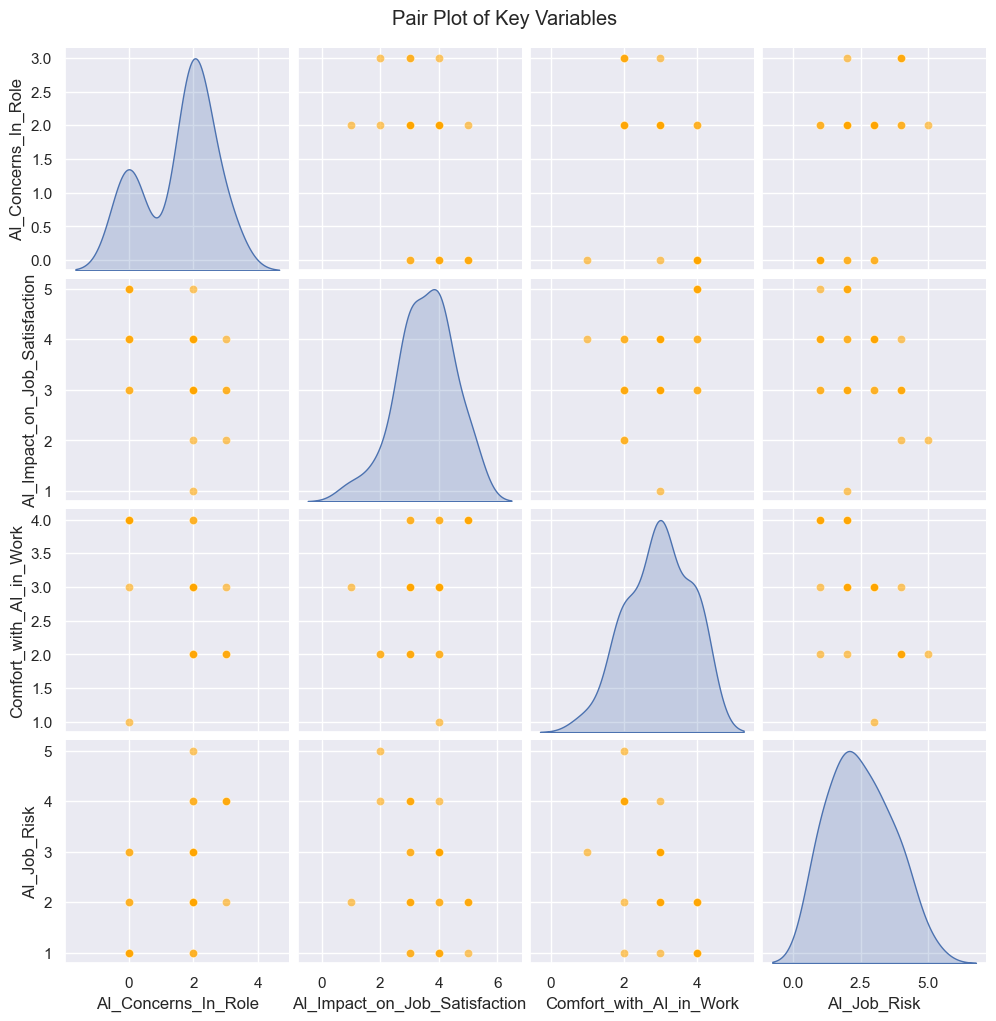

In [90]:
# List of columns of interest for scatter plots
columns_of_interest = [
    'AI_Concerns_In_Role',
    'AI_Impact_on_Job_Satisfaction',
    'Comfort_with_AI_in_Work',
    'AI_Job_Risk'
]

# Create a pairplot with orange color and common points
sns.pairplot(cleaned_data[columns_of_interest], 
             plot_kws={'color': 'orange', 'alpha': 0.6},  # Set color and transparency
             diag_kind='kde',  # Change to 'kde' or 'hist' if desired
             markers='o')  # Use markers to indicate common points

plt.suptitle('Pair Plot of Key Variables', y=1.02)  # Adjust title position
plt.show()

c:\Users\sally\anaconda3\envs\block_b\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


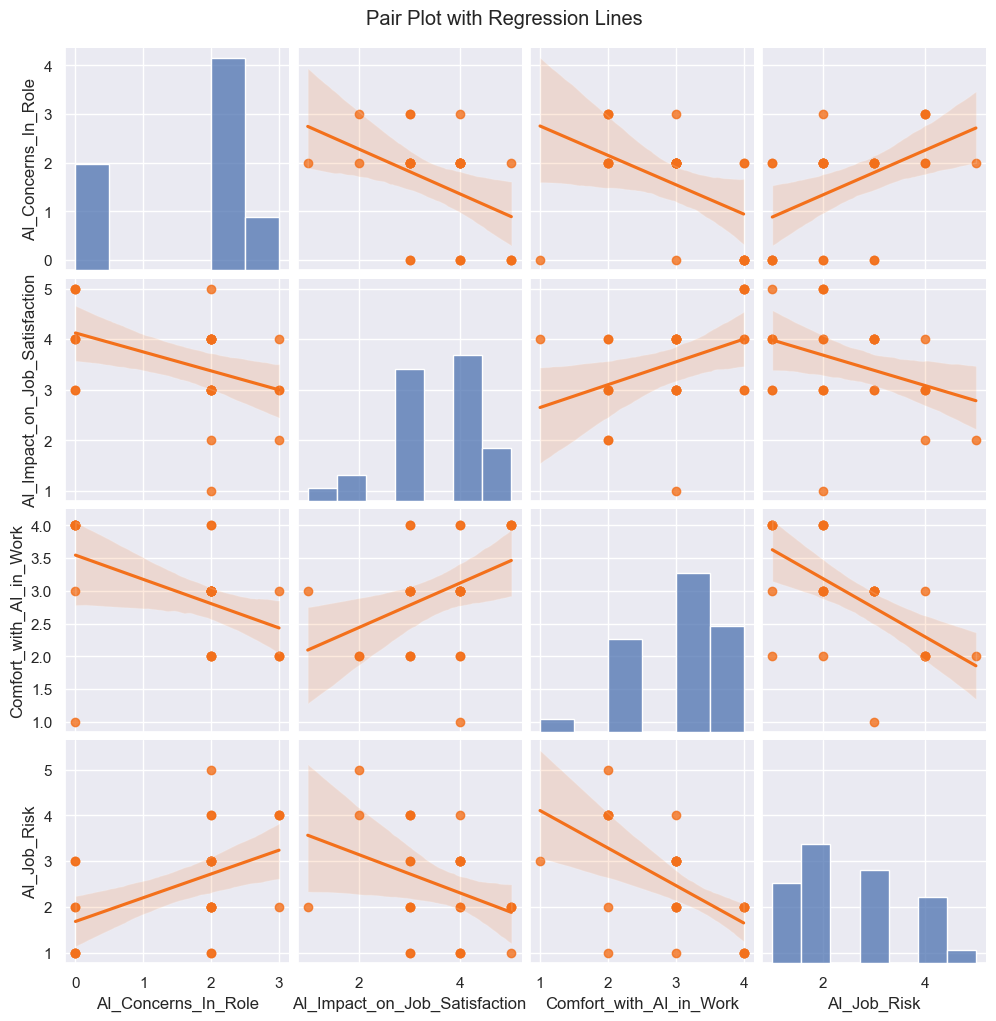

In [102]:
# Specify the columns of interest
columns_of_interest = [
    'AI_Concerns_In_Role',
    'AI_Impact_on_Job_Satisfaction',
    'Comfort_with_AI_in_Work',
    'AI_Job_Risk',
    'Text_Generation_Familiarity',
    'Image_Generation_Familiarity'
]

# Create a pair plot with regression lines and Oranges color map
sns.pairplot(
    cleaned_data[columns_of_interest],
    kind='reg',
    plot_kws={'color': cm.Oranges(0.6)}  # Adjust the shade of orange as desired
)
plt.suptitle('Pair Plot with Regression Lines', y=1.02)  # Adjust title position

# Save with transparent background
plt.savefig('pair_plot_transparent.png', transparent=True)

plt.show()